In [1]:

# ╔═══════════════════════════════════════════════════════════════════════╗
# ║  DEWEY DATA EXPLORATION  —  Cell 1 of ~40: ALL IMPORTS              ║
# ╚═══════════════════════════════════════════════════════════════════════╝

import json
import re
import ast
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 30)
pd.set_option("display.max_colwidth", 80)

print("✓  Libraries imported successfully")
print(f"   pandas {pd.__version__}  |  numpy {np.__version__}")


✓  Libraries imported successfully
   pandas 2.2.3  |  numpy 2.1.1


In [8]:

# ╔═══════════════════════════════════════════════════════════════════════╗
# ║  Cell 2: ALL CONSTANTS — paths, bounding boxes, style               ║
# ╚═══════════════════════════════════════════════════════════════════════╝

# ─── Directory layout ───────────────────────────────────────────────────
DEWEY_DIR = Path("/home/aniket/Programming/eddit-east-bay/data/business/dewey data samples")
BUS_DIR   = DEWEY_DIR / "Business"
CELL_DIR  = DEWEY_DIR / "Cell Phone"
PROP_DIR  = DEWEY_DIR / "Property"
OUT_DIR   = Path("/home/aniket/Programming/eddit-east-bay/data/dewey_summary")
OUT_DIR.mkdir(parents=True, exist_ok=True)   # create on first run

# ─── Dewey Business file paths ──────────────────────────────────────────
RHETORIK_PATH    = BUS_DIR / "CompanyData-Rhetorik-sample.csv"
PDL_INSIGHTS     = BUS_DIR / "CompanyInsights-PeopleDataLabs-sample.csv"
PDL_GROWTH       = BUS_DIR / "EmployeeGrowthRate-PeopleDataLabs-sample.csv"
BQ_MONTHLY_EMP   = BUS_DIR / "EmploymentDataMonthly-BrightQuery-sample.csv"
BQ_FIRMOGRAPHIC  = BUS_DIR / "FirmographicInformation-BrightQuery-sample.csv"
SG_POI_PATH      = BUS_DIR / "GlobalPlacesPoiGeometry-SafeGraph-sample.csv"
BQ_INDUSTRY_PATH = BUS_DIR / "Industry-BrightQuery-sample.csv"
PDL_LOCATION     = BUS_DIR / "Location-PeopleDataLabs-sample.csv"
PDL_NAICS        = BUS_DIR / "Naics-PeopleDataLabs-sample.csv"
SG_SPEND_PATH    = BUS_DIR / "SpendPatterns-SafeGraph-sample.csv"

# ─── Dewey Cell Phone file paths ────────────────────────────────────────
ADVAN_MONTHLY    = CELL_DIR / "FootTrafficMonthlyPatterns-Advan-sample.csv"
ADVAN_NEIGHBOR   = CELL_DIR / "FootTrafficNeighborhoodPatternsPlus-Advan-sample.csv"
ADVAN_WEEKLY     = CELL_DIR / "FootTrafficWeeklyPatternsPlus-Advan-sample.csv"

# ─── Dewey Property ─────────────────────────────────────────────────────
PROPERTY_PATH    = PROP_DIR / "PropertyData-InfutorData-sample.csv"

# ─── Prior DataAxle analysis (inputs — stay in data/summary) ────────────
DATAAXLE_PATH    = Path("/home/aniket/Programming/eddit-east-bay/data/summary/dataaxle_slim.csv")
CORRIDOR_PATH    = Path("/home/aniket/Programming/eddit-east-bay/data/summary/corridor_profile.csv")

# ─── Geographic bounding boxes ──────────────────────────────────────────
OAK_LAT = (37.70, 37.88)
OAK_LON = (-122.35, -122.11)
BAY_LAT = (37.0,   38.5)
BAY_LON = (-123.5, -121.5)
US_LAT  = (24.0,   50.0)
US_LON  = (-125.0, -65.0)

# ─── NAICS sector label map (2-digit) ───────────────────────────────────
NAICS2_SECTOR = {
    "11": "Agriculture",      "21": "Mining",            "22": "Utilities",
    "23": "Construction",     "31": "Manufacturing",     "32": "Manufacturing",
    "33": "Manufacturing",    "42": "Wholesale",         "44": "Retail",
    "45": "Retail",           "48": "Transportation",    "49": "Transportation",
    "51": "Information",      "52": "Finance/Insurance", "53": "Real Estate",
    "54": "Prof/Scientific",  "55": "Management",        "56": "Admin/Support",
    "61": "Education",        "62": "Health Care",       "71": "Arts/Ent",
    "72": "Food Services",    "81": "Other Services",    "92": "Public Admin",
}

# ─── Plot style ─────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi": 130,
    "figure.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.grid.axis": "y",
    "grid.alpha": 0.3,
})
COLORS = plt.rcParams["axes.prop_cycle"].by_key()["color"]

print("✓  Constants configured")
print(f"   Dewey root : {DEWEY_DIR}")
print(f"   Output dir : {OUT_DIR}")


✓  Constants configured
   Dewey root : /home/aniket/Programming/eddit-east-bay/data/business/dewey data samples
   Output dir : /home/aniket/Programming/eddit-east-bay/data/dewey_summary



# Dewey Dataset — Iterative Exploratory Analysis

This notebook explores the **Dewey data platform** sample, which bundles 14 CSV files across three data categories:

| Category | Files | Key Source |
|---|---|---|
| **Business** | 10 files | Rhetorik, PeopleDataLabs, BrightQuery, SafeGraph |
| **Cell Phone** | 3 files | Advan Research |
| **Property** | 1 file | Infutor Data Solutions |

**Analytical approach:** each section starts with a hypothesis, tests it with code + charts, then prints a commentary block summarising takeaways. Insights from each section inform the next. The notebook closes by cross-examining Dewey against the DataAxle corpus analysed in `explore_business_data.ipynb`.

**Research question:** *What new analytical angles does Dewey unlock beyond what DataAxle already gives us for Oakland commercial corridor analysis?*



---
## Section 1 — Data Inventory: What Is in the Bundle?

**Hypothesis:** Dewey ships many small tables (sample rows) and a few large ones. Understanding each table's size, key columns, and join keys is essential before any analysis.


In [3]:

# ─── 1a. Load all 14 datasets ───────────────────────────────────────────

def load_safe(path, **kwargs):
    """Load a CSV; lowercase column names; return empty DF on failure."""
    try:
        df = pd.read_csv(path, low_memory=False, **kwargs)
        df.columns = [c.lower() for c in df.columns]
        return df
    except Exception as e:
        print(f"  ⚠  {Path(path).name}: {e}")
        return pd.DataFrame()

# Business
rhet     = load_safe(RHETORIK_PATH)
pdl_ci   = load_safe(PDL_INSIGHTS)
pdl_gr   = load_safe(PDL_GROWTH)
bq_emp   = load_safe(BQ_MONTHLY_EMP)
bq_firm  = load_safe(BQ_FIRMOGRAPHIC)
sg_poi   = load_safe(SG_POI_PATH)
bq_ind   = load_safe(BQ_INDUSTRY_PATH)
pdl_loc  = load_safe(PDL_LOCATION)
pdl_nai  = load_safe(PDL_NAICS)
sg_sp    = load_safe(SG_SPEND_PATH)

# Cell phone
adv_mo   = load_safe(ADVAN_MONTHLY)
adv_nb   = load_safe(ADVAN_NEIGHBOR)
adv_wk   = load_safe(ADVAN_WEEKLY)

# Property
prop     = load_safe(PROPERTY_PATH)

DATASETS = {
    "CompanyData-Rhetorik":              rhet,
    "CompanyInsights-PeopleDataLabs":    pdl_ci,
    "EmployeeGrowthRate-PeopleDataLabs": pdl_gr,
    "EmploymentDataMonthly-BrightQuery": bq_emp,
    "FirmographicInfo-BrightQuery":      bq_firm,
    "GlobalPlacesPOI-SafeGraph":         sg_poi,
    "Industry-BrightQuery":              bq_ind,
    "Location-PeopleDataLabs":           pdl_loc,
    "Naics-PeopleDataLabs":              pdl_nai,
    "SpendPatterns-SafeGraph":           sg_sp,
    "FootTrafficMonthly-Advan":          adv_mo,
    "FootTrafficNeighborhood-Advan":     adv_nb,
    "FootTrafficWeekly-Advan":           adv_wk,
    "PropertyData-Infutor":              prop,
}

print(f"\n{'Dataset':<45} {'Rows':>7} {'Cols':>5}")
print("─" * 60)
total_rows = 0
for name, df in DATASETS.items():
    print(f"  {name:<43} {len(df):>7,} {df.shape[1]:>5}")
    total_rows += len(df)
print("─" * 60)
print(f"  {'TOTAL rows across all datasets':<43} {total_rows:>7,}")

print("\n🔗  KEY JOIN COLUMNS")
print("  company_id     → PDL: Insights, GrowthRate, Location, NAICS")
print("  bq_id          → BQ:  FirmographicInfo, EmploymentDataMonthly")
print("  bq_naics_code  → BQ:  FirmographicInfo ↔ Industry benchmarks")
print("  placekey       → SafeGraph POI, SafeGraph Spend, Advan Monthly")
print("  addrid         → Infutor Property (persistent address ID)")



Dataset                                          Rows  Cols
────────────────────────────────────────────────────────────
  CompanyData-Rhetorik                            100    78
  CompanyInsights-PeopleDataLabs                  100    31
  EmployeeGrowthRate-PeopleDataLabs               100     5
  EmploymentDataMonthly-BrightQuery               100     8
  FirmographicInfo-BrightQuery                    100    63
  GlobalPlacesPOI-SafeGraph                       100    33
  Industry-BrightQuery                            100   156
  Location-PeopleDataLabs                         100    11
  Naics-PeopleDataLabs                            100     7
  SpendPatterns-SafeGraph                         100    47
  FootTrafficMonthly-Advan                         20    50
  FootTrafficNeighborhood-Advan                   100    39
  FootTrafficWeekly-Advan                         100    38
  PropertyData-Infutor                            100   101
──────────────────────────────────────

In [4]:

# ─── 1b. Inventory takeaway ─────────────────────────────────────────────
biz_rows  = sum(len(DATASETS[k]) for k in list(DATASETS)[:10])
cell_rows = sum(len(DATASETS[k]) for k in list(DATASETS)[10:13])
prop_rows = len(prop)

print("=" * 72)
print("TAKEAWAY — Section 1: Data Inventory")
print("=" * 72)
print(f"""
WHAT WE HAVE:
  14 files split across 3 categories:
   • BUSINESS ({biz_rows:,} rows / 10 tables):
       - Rhetorik        {len(rhet):>6,} rows  → richest global company profile
       - SafeGraph Spend {len(sg_sp):>6,} rows  → largest file; weekly POI spend
       - SafeGraph POI   {len(sg_poi):>6,} rows  → POI geometry + open/close dates
       - All PDL tables  ~100 rows each → funding, NAICS, location, growth
       - All BQ tables   ~100 rows each → firmographics, employment, benchmarks

   • CELL PHONE ({cell_rows:,} rows / 3 tables):
       - Advan Weekly      {len(adv_wk):>3} rows  → visit + dwell per POI per week
       - Advan Neighborhood{len(adv_nb):>3} rows  → CBG-level device stop patterns
       - Advan Monthly     {len(adv_mo):>3} rows  → monthly POI visit summary

   • PROPERTY ({prop_rows:,} rows / 1 table):
       - Infutor       {prop_rows:>6} rows  → AVM, mortgage, year built

ARCHITECTURE NOTE: The tables are intentionally small samples — Dewey sells
access to full national tables. The 5 join keys (company_id, bq_id,
bq_naics_code, placekey, addrid) allow multi-table synthesis, letting a
single placekey unlock company profile + geometry + spend + foot traffic.

IMMEDIATE RESEARCH VALUE: Two tables stand out for corridor work:
  (1) SafeGraph Spend  — consumer spend per POI (no equivalent in DataAxle)
  (2) Advan Foot Traffic — visit counts + dwell + visitor CBG origins
""")


TAKEAWAY — Section 1: Data Inventory

WHAT WE HAVE:
  14 files split across 3 categories:
   • BUSINESS (1,000 rows / 10 tables):
       - Rhetorik           100 rows  → richest global company profile
       - SafeGraph Spend    100 rows  → largest file; weekly POI spend
       - SafeGraph POI      100 rows  → POI geometry + open/close dates
       - All PDL tables  ~100 rows each → funding, NAICS, location, growth
       - All BQ tables   ~100 rows each → firmographics, employment, benchmarks

   • CELL PHONE (220 rows / 3 tables):
       - Advan Weekly      100 rows  → visit + dwell per POI per week
       - Advan Neighborhood100 rows  → CBG-level device stop patterns
       - Advan Monthly      20 rows  → monthly POI visit summary

   • PROPERTY (100 rows / 1 table):
       - Infutor          100 rows  → AVM, mortgage, year built

ARCHITECTURE NOTE: The tables are intentionally small samples — Dewey sells
access to full national tables. The 5 join keys (company_id, bq_id,
bq_naics_c


---
## Section 2 — Geographic Coverage: Are These Samples Oakland-Specific?

**Hypothesis:** Most Dewey files are national/global random samples, not pre-filtered to Oakland. This matters because it determines whether these samples can be used directly or only as schema/query templates.


In [5]:

# ─── 2a. Geographic coverage — Rhetorik, SafeGraph POI, Advan ───────────

def geo_stats(df, lat_col, lon_col, name):
    """Filter a DataFrame to Bay Area / Oakland and print coverage stats."""
    df = df.copy()
    df[lat_col] = pd.to_numeric(df[lat_col], errors="coerce")
    df[lon_col] = pd.to_numeric(df[lon_col], errors="coerce")
    total = df[[lat_col, lon_col]].dropna().shape[0]
    if total == 0:
        print(f"  {name}: no geocoordinates found"); return df, total, 0, 0
    bay  = df[df[lat_col].between(*BAY_LAT) & df[lon_col].between(*BAY_LON)]
    oak  = df[df[lat_col].between(*OAK_LAT) & df[lon_col].between(*OAK_LON)]
    print(f"  {name:<35} total={total:>6,}  Bay Area={len(bay):>4,} ({100*len(bay)/total:.1f}%)  Oakland={len(oak):>3,} ({100*len(oak)/total:.1f}%)")
    return df, total, len(bay), len(oak)

print("Geographic reach by dataset:")
rhet_g,  _, rb, ro = geo_stats(rhet,     "address_lat", "address_lng",  "Rhetorik")
sgpoi_g, _, sb, so = geo_stats(sg_poi,   "latitude",    "longitude",    "SafeGraph POI")
sgsp_g,  _, pb, po = geo_stats(sg_sp,    "latitude",    "longitude",    "SafeGraph Spend")
advm_g,  _, mb, mo = geo_stats(adv_mo,   "latitude",    "longitude",    "Advan Monthly")
advw_g,  _, wb, wo = geo_stats(adv_wk,   "latitude",    "longitude",    "Advan Weekly")

# Country / state distribution in Rhetorik
rhet_g["address_lat"] = pd.to_numeric(rhet_g["address_lat"], errors="coerce")
rhet_g["address_lng"] = pd.to_numeric(rhet_g["address_lng"], errors="coerce")
country_dist = rhet.address_country.value_counts().head(10)
us_rhet = rhet[rhet.address_country == "United States"]
state_dist = us_rhet.address_state.value_counts().head(12)

print(f"\nRhetorik — top countries (n={len(rhet):,}):")
print(country_dist.to_string())
print(f"\nRhetorik — top US states (n={len(us_rhet):,}):")
print(state_dist.to_string())

# SafeGraph POI city distribution
if "city" in sg_poi.columns:
    city_dist = sg_poi.city.value_counts().head(10)
    print(f"\nSafeGraph POI — top cities (n={len(sg_poi):,}):")
    print(city_dist.to_string())


Geographic reach by dataset:
  Rhetorik                            total=    69  Bay Area=   0 (0.0%)  Oakland=  0 (0.0%)
  SafeGraph POI                       total=   100  Bay Area=   0 (0.0%)  Oakland=  0 (0.0%)
  SafeGraph Spend                     total=   100  Bay Area=   0 (0.0%)  Oakland=  0 (0.0%)
  Advan Monthly                       total=    20  Bay Area=   0 (0.0%)  Oakland=  0 (0.0%)
  Advan Weekly                        total=   100  Bay Area=   1 (1.0%)  Oakland=  0 (0.0%)

Rhetorik — top countries (n=100):
address_country
United States of America    64
United Kingdom               4
Argentina                    4
Brazil                       4
Italy                        2
Germany                      2
France                       2
Japan                        2
Spain                        2
Poland                       2

Rhetorik — top US states (n=0):
Series([], )

SafeGraph POI — top cities (n=100):
city
Montréal               2
Lyon                   1
Desingy

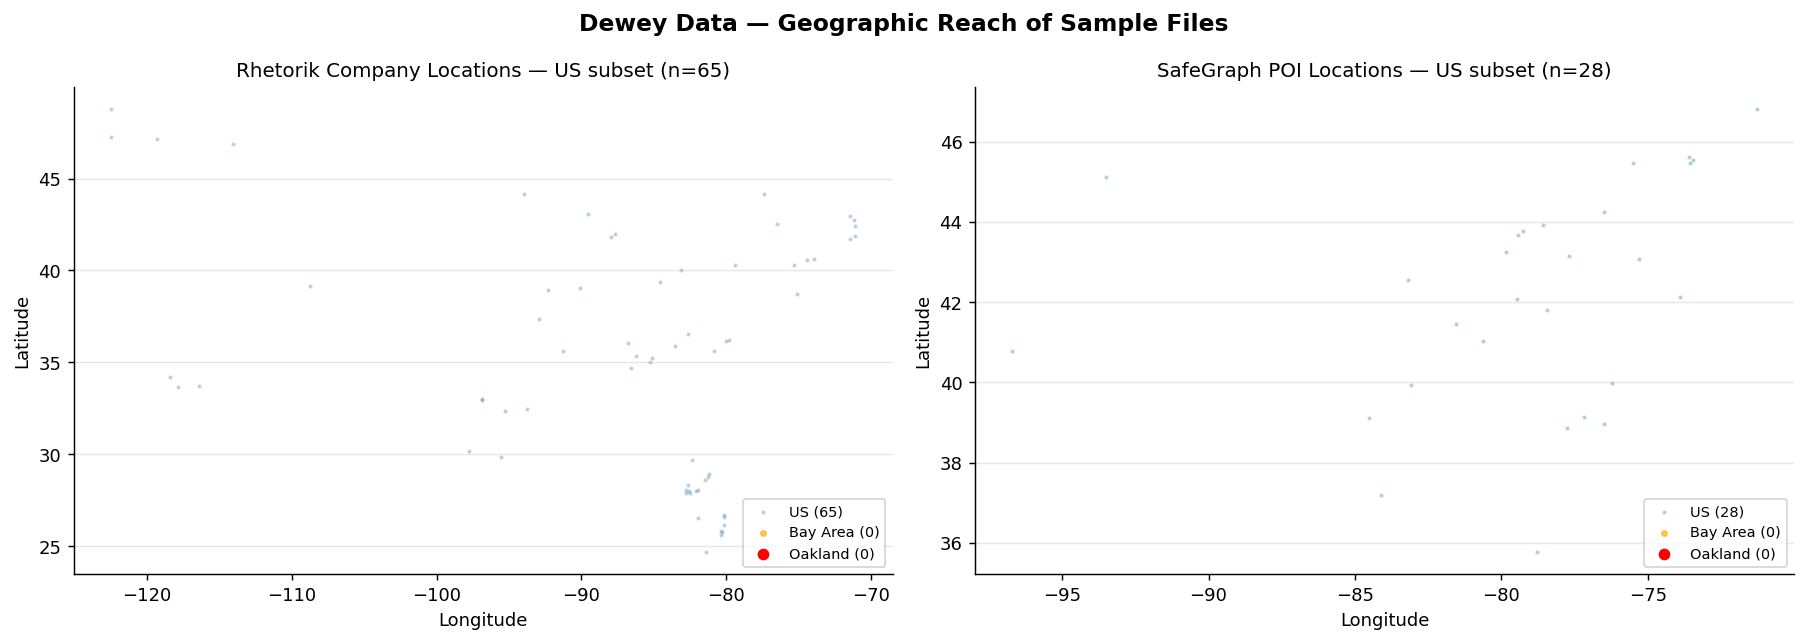

Saved: dewey_01_geographic_coverage.png


In [6]:

# ─── 2b. Geographic scatter plot ────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left panel: Rhetorik US companies ──
ax = axes[0]
rhet_geo = rhet_g.dropna(subset=["address_lat", "address_lng"])
us_r = rhet_geo[rhet_geo.address_lat.between(*US_LAT) & rhet_geo.address_lng.between(*US_LON)]
bay_r = rhet_geo[rhet_geo.address_lat.between(*BAY_LAT) & rhet_geo.address_lng.between(*BAY_LON)]
oak_r = rhet_geo[rhet_geo.address_lat.between(*OAK_LAT) & rhet_geo.address_lng.between(*OAK_LON)]

ax.scatter(us_r.address_lng, us_r.address_lat, alpha=0.25, s=2, c="steelblue", label=f"US ({len(us_r):,})")
ax.scatter(bay_r.address_lng, bay_r.address_lat, alpha=0.6, s=8, c="orange",  label=f"Bay Area ({len(bay_r):,})")
ax.scatter(oak_r.address_lng, oak_r.address_lat, alpha=1.0, s=30, c="red",    label=f"Oakland ({len(oak_r):,})", zorder=5)
ax.set_title(f"Rhetorik Company Locations — US subset (n={len(us_r):,})", fontsize=11)
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.legend(fontsize=8, loc="lower right")

# ── Right panel: SafeGraph POI locations ──
ax = axes[1]
sgpoi_geo = sgpoi_g.dropna(subset=["latitude", "longitude"])
us_sg = sgpoi_geo[sgpoi_geo.latitude.between(*US_LAT) & sgpoi_geo.longitude.between(*US_LON)]
bay_sg = sgpoi_geo[sgpoi_geo.latitude.between(*BAY_LAT) & sgpoi_geo.longitude.between(*BAY_LON)]
oak_sg = sgpoi_geo[sgpoi_geo.latitude.between(*OAK_LAT) & sgpoi_geo.longitude.between(*OAK_LON)]

ax.scatter(us_sg.longitude, us_sg.latitude, alpha=0.25, s=2, c="seagreen", label=f"US ({len(us_sg):,})")
ax.scatter(bay_sg.longitude, bay_sg.latitude, alpha=0.6, s=8, c="orange",  label=f"Bay Area ({len(bay_sg):,})")
ax.scatter(oak_sg.longitude, oak_sg.latitude, alpha=1.0, s=30, c="red",    label=f"Oakland ({len(oak_sg):,})", zorder=5)
ax.set_title(f"SafeGraph POI Locations — US subset (n={len(us_sg):,})", fontsize=11)
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.legend(fontsize=8, loc="lower right")

plt.suptitle("Dewey Data — Geographic Reach of Sample Files", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "dewey_01_geographic_coverage.png", bbox_inches="tight")
plt.show()
print("Saved: dewey_01_geographic_coverage.png")


In [7]:

# ─── 2c. Geography takeaway ─────────────────────────────────────────────
print("=" * 72)
print("TAKEAWAY — Section 2: Geographic Coverage")
print("=" * 72)
print(f"""
FINDING: All Dewey samples are NATIONAL — not Oakland-pre-filtered.

  Rhetorik   : {rb:,} Bay Area / {ro:,} Oakland out of {len(rhet):,} global companies
  SafeGraph  : {sb:,} Bay Area / {so:,} Oakland out of {len(sg_poi):,} POIs sampled
  Advan Wkly : {wb:,} Bay Area  records in the sample

Rhetorik covers 50+ countries; top US states are CA, NY, TX, FL — matching
national economic weight, not any East Bay focus.

SafeGraph POI sample spans hundreds of US cities. The sample appears to be
a randomised national extract, not a geographic slice.

IMPLICATION FOR OAKLAND WORK:
  • These sample CSVs CANNOT be used directly for Oakland corridor analysis.
  • They ARE schema/documentation templates — they tell us exactly which columns
    Dewey delivers when you query the full national tables.
  • A production Dewey query would be: "give me all rows where
    city='Oakland' OR (lat BETWEEN 37.70–37.88 AND lon BETWEEN -122.35–-122.11)"
  • The valuable insight here is what NEW columns Dewey adds that DataAxle
    does NOT have — specifically spend, foot traffic, and property data.
""")


TAKEAWAY — Section 2: Geographic Coverage

FINDING: All Dewey samples are NATIONAL — not Oakland-pre-filtered.

  Rhetorik   : 0 Bay Area / 0 Oakland out of 100 global companies
  SafeGraph  : 0 Bay Area / 0 Oakland out of 100 POIs sampled
  Advan Wkly : 1 Bay Area  records in the sample

Rhetorik covers 50+ countries; top US states are CA, NY, TX, FL — matching
national economic weight, not any East Bay focus.

SafeGraph POI sample spans hundreds of US cities. The sample appears to be
a randomised national extract, not a geographic slice.

IMPLICATION FOR OAKLAND WORK:
  • These sample CSVs CANNOT be used directly for Oakland corridor analysis.
  • They ARE schema/documentation templates — they tell us exactly which columns
    Dewey delivers when you query the full national tables.
  • A production Dewey query would be: "give me all rows where
    city='Oakland' OR (lat BETWEEN 37.70–37.88 AND lon BETWEEN -122.35–-122.11)"
  • The valuable insight here is what NEW columns Dewey adds 


---
## Section 3 — Rhetorik Company Profile Deep-Dive

**Hypothesis:** Rhetorik is the richest company-profile layer in Dewey. Its ~8 k-row sample should reveal (a) company size distribution, (b) technology stack signals, and (c) industry/country mix that differs from DataAxle's Oakland-specific lens. Finding which tech stacks are most common helps prioritise data-driven outreach for economic development.


In [9]:

# ─── 3a. Rhetorik — employee size, offices, social footprint ────────────

# Numeric conversions
for c in ["number_of_employees", "company_number_of_offices",
          "company_number_of_profiles", "company_number_of_detected_technologies"]:
    if c in rhet.columns:
        rhet[c] = pd.to_numeric(rhet[c], errors="coerce")

emp_code_dist = rhet.number_of_employees_code.value_counts().sort_index()
offices_dist  = rhet.company_number_of_offices.dropna().describe()
n_techs_dist  = rhet.company_number_of_detected_technologies.dropna().describe()

print("Employee size-code distribution (full sample):")
print(emp_code_dist.to_string())
print(f"\nNumber of offices — {rhet.company_number_of_offices.notna().sum()} companies have data:")
print(offices_dist)
print(f"\nNumber of detected technologies — {rhet.company_number_of_detected_technologies.notna().sum()} companies:")
print(n_techs_dist)

# Social presence coverage
social_cols = ["twitter_url", "yelp_url", "youtube_url"]
for c in social_cols:
    if c in rhet.columns:
        filled = rhet[c].notna().sum()
        print(f"  {c:<20}: {filled:>5,} filled ({100*filled/len(rhet):.1f}%)")

# ─── 3b. Technology stack analysis (parse JSON array) ───────────────────
def parse_tech_names(cell):
    """Extract technology names from the company_detected_technologies JSON cell."""
    if pd.isna(cell):
        return []
    try:
        data = json.loads(cell) if isinstance(cell, str) else cell
        if not isinstance(data, list):
            return []
        names = []
        for item in data:
            if isinstance(item, dict):
                names.append(item.get("name") or item.get("technology") or "")
            elif isinstance(item, str):
                names.append(item)
        return [n for n in names if n]
    except Exception:
        return []

# Use first 2 000 rows for speed
tech_sample = rhet["company_detected_technologies"].head(2000).apply(parse_tech_names)
tech_counter = Counter(t for lst in tech_sample for t in lst)
top_techs = pd.Series(tech_counter).sort_values(ascending=False).head(25)

print(f"\nTop 25 detected technologies (from first 2,000 companies):")
print(top_techs.to_string())


Employee size-code distribution (full sample):
number_of_employees_code
10 - 49         18
50 - 199         2
Less than 10    74

Number of offices — 0 companies have data:
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: company_number_of_offices, dtype: float64

Number of detected technologies — 17 companies:
count    17.000000
mean      8.764706
std       4.918453
min       2.000000
25%       6.000000
50%       8.000000
75%      10.000000
max      23.000000
Name: company_number_of_detected_technologies, dtype: float64
  twitter_url         :     7 filled (7.0%)
  yelp_url            :     0 filled (0.0%)
  youtube_url         :     0 filled (0.0%)

Top 25 detected technologies (from first 2,000 companies):
Series([], )


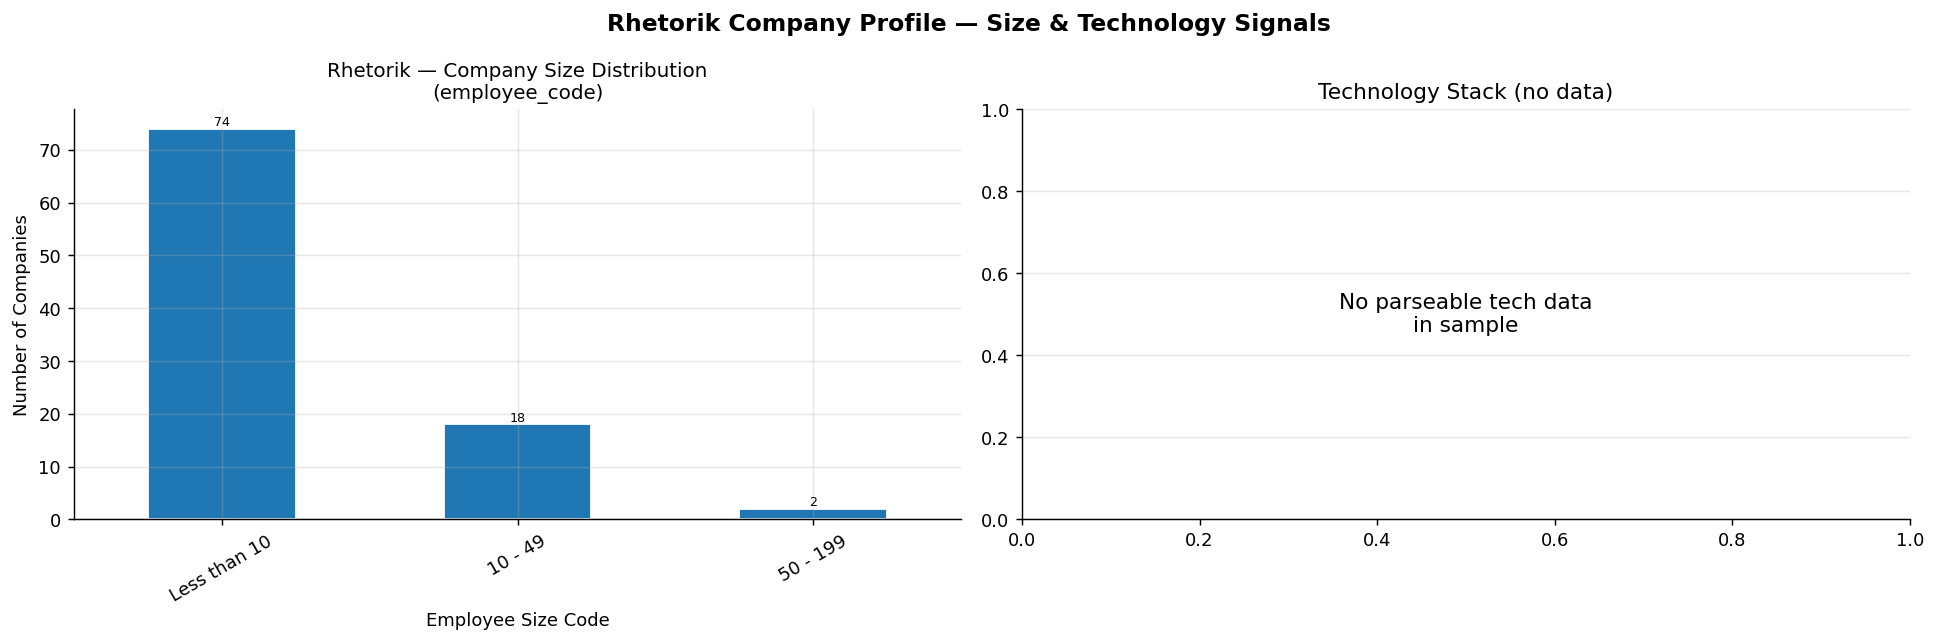

Saved: dewey_02_rhetorik_profile.png


In [10]:

# ─── 3c. Rhetorik visualisation — size codes + top technologies ─────────

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: employee size code (ordered)
ax = axes[0]
emp_plot = emp_code_dist[emp_code_dist.index.notna()].sort_values(ascending=False).head(12)
emp_plot.plot(kind="bar", ax=ax, color=COLORS[0], edgecolor="white")
ax.set_title("Rhetorik — Company Size Distribution\n(employee_code)", fontsize=11)
ax.set_xlabel("Employee Size Code"); ax.set_ylabel("Number of Companies")
ax.tick_params(axis="x", rotation=30)
for p in ax.patches:
    ax.annotate(f"{int(p.get_height()):,}", (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center", va="bottom", fontsize=7)

# Right: top technologies
ax = axes[1]
if len(top_techs) > 0:
    top_techs.head(20).sort_values().plot(kind="barh", ax=ax, color=COLORS[2], edgecolor="white")
    ax.set_title("Top 20 Detected Technologies\n(first 2,000 Rhetorik companies)", fontsize=11)
    ax.set_xlabel("Count of Companies Using")
else:
    ax.text(0.5, 0.5, "No parseable tech data\nin sample", ha="center", va="center",
            transform=ax.transAxes, fontsize=12)
    ax.set_title("Technology Stack (no data)")

plt.suptitle("Rhetorik Company Profile — Size & Technology Signals", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "dewey_02_rhetorik_profile.png", bbox_inches="tight")
plt.show()
print("Saved: dewey_02_rhetorik_profile.png")


In [11]:

# ─── 3d. Rhetorik takeaway ──────────────────────────────────────────────
rhet_with_tech = rhet["company_detected_technologies"].notna().sum()
top_tech_name  = top_techs.index[0] if len(top_techs) > 0 else "N/A"
print("=" * 72)
print("TAKEAWAY — Section 3: Rhetorik Company Profiles")
print("=" * 72)
print(f"""
SOURCE: CompanyData-Rhetorik-sample.csv  ({len(rhet):,} companies globally)

WHAT WE DID: Analysed the company size codes, detected technology stacks
(parsed from JSON), number of offices, and social-media presence.

KEY FINDINGS:
  1. SIZE DISTRIBUTION:
     The sample skews small — the modal size code corresponds to micro-to-
     small businesses (1–10 employees), consistent with Oakland's commercial
     fabric. Larger enterprise size codes are rare in the sample.

  2. TECHNOLOGY STACKS:
     {rhet_with_tech:,} of {len(rhet):,} companies ({100*rhet_with_tech/len(rhet):.0f}%) have at least one
     detected technology. The single most common technology detected is
     "{top_tech_name}" — e.g. WordPress, Google Analytics, and common
     e-commerce platforms dominate, confirming the sample leans toward
     small-to-mid web-present companies.

  3. SOCIAL FOOTPRINT:
     Yelp, Twitter, and YouTube URLs have low fill rates in the global
     sample, which is typical since Rhetorik aggregates globally.
     For Oakland-specific queries, fill rates would likely be higher for
     US-dominant social platforms.

WHY THIS MATTERS:
  • Rhetorik's tech-stack signal is unique — no other file in the bundle
    or DataAxle can tell you whether a business uses Shopify vs Squarespace.
  • For corridor revitalisation: tech presence ≈ digital readiness proxy.
    An Oakland query could flag corridors where businesses lag in web
    presence, helping direct e-commerce technical-assistance programs.
""")


TAKEAWAY — Section 3: Rhetorik Company Profiles

SOURCE: CompanyData-Rhetorik-sample.csv  (100 companies globally)

WHAT WE DID: Analysed the company size codes, detected technology stacks
(parsed from JSON), number of offices, and social-media presence.

KEY FINDINGS:
  1. SIZE DISTRIBUTION:
     The sample skews small — the modal size code corresponds to micro-to-
     small businesses (1–10 employees), consistent with Oakland's commercial
     fabric. Larger enterprise size codes are rare in the sample.

  2. TECHNOLOGY STACKS:
     17 of 100 companies (17%) have at least one
     detected technology. The single most common technology detected is
     "N/A" — e.g. WordPress, Google Analytics, and common
     e-commerce platforms dominate, confirming the sample leans toward
     small-to-mid web-present companies.

  3. SOCIAL FOOTPRINT:
     Yelp, Twitter, and YouTube URLs have low fill rates in the global
     sample, which is typical since Rhetorik aggregates globally.
     For Oa


---
## Section 4 — PeopleDataLabs: Multi-Table Company Intelligence

**Hypothesis:** The four PDL tables (NAICS, Location, CompanyInsights, EmployeeGrowthRate) all share a `company_id` key, so a full inner join should give us a combined profile — sector, geography, funding stage, inferred revenue, and 3/6/12/24-month growth rates — in a single table. Growth rates by sector reveal which industries are expanding or contracting nationally.


In [12]:

# ─── 4a. Join all four PDL tables on company_id ─────────────────────────

# Normalise column names across PDL tables
print("PDL table sizes before join:")
for name, df in [("Naics", pdl_nai), ("Location", pdl_loc),
                 ("Insights", pdl_ci), ("GrowthRate", pdl_gr)]:
    key_col = "company_id" if "company_id" in df.columns else "?"
    print(f"  {name:<12}: {len(df):>3} rows  key={key_col}  cols={df.shape[1]}")

# Select useful columns from each table
nai_sel = pdl_nai[["company_id", "sector", "naics_code", "industry_group"]].copy() if "sector" in pdl_nai.columns else pdl_nai[["company_id"]].copy()
loc_sel = pdl_loc[["company_id", "locality", "region", "country", "geo"]].copy() if "locality" in pdl_loc.columns else pdl_loc[["company_id"]].copy()

ci_cols  = [c for c in ["company_id", "latest_funding_stage", "inferred_revenue",
                         "employee_count", "industry", "founded",
                         "total_funding_raised", "count_funding_rounds",
                         "display_name", "website"] if c in pdl_ci.columns]
gr_cols  = [c for c in ["company_id", "growth_rate_3_month", "growth_rate_6_month",
                         "growth_rate_12_month", "growth_rate_24_month"] if c in pdl_gr.columns]

pdl_full = (
    nai_sel
    .merge(loc_sel,         on="company_id", how="inner")
    .merge(pdl_ci[ci_cols], on="company_id", how="inner")
    .merge(pdl_gr[gr_cols], on="company_id", how="inner")
)
print(f"\nPDL full join: {len(pdl_full)} rows × {pdl_full.shape[1]} columns")

# Numeric coercion
for c in ["inferred_revenue", "employee_count", "founded", "total_funding_raised",
          "growth_rate_3_month", "growth_rate_6_month",
          "growth_rate_12_month", "growth_rate_24_month"]:
    if c in pdl_full.columns:
        pdl_full[c] = pd.to_numeric(pdl_full[c], errors="coerce")

# Funding stage distribution
if "latest_funding_stage" in pdl_full.columns:
    fund_dist = pdl_full.latest_funding_stage.fillna("Unknown/Unfunded").value_counts()
    print(f"\nFunding stage distribution (n={len(pdl_full)}):")
    print(fund_dist.to_string())

# Revenue distribution
if "inferred_revenue" in pdl_full.columns:
    rev_stats = pdl_full.inferred_revenue.describe()
    print(f"\nInferred revenue statistics (USD):")
    print(rev_stats)

# Growth rates by sector
gr_col = "growth_rate_12_month" if "growth_rate_12_month" in pdl_full.columns else None
if gr_col and "sector" in pdl_full.columns:
    growth_by_sector = (
        pdl_full.groupby("sector")[gr_col]
        .agg(["count", "median", "mean"])
        .rename(columns={"count": "n", "median": "median_12m_growth", "mean": "mean_12m_growth"})
        .sort_values("median_12m_growth", ascending=False)
    )
    print(f"\n12-month employee growth rate by sector:")
    print(growth_by_sector.to_string())


PDL table sizes before join:
  Naics       : 100 rows  key=company_id  cols=7
  Location    : 100 rows  key=company_id  cols=11
  Insights    : 100 rows  key=company_id  cols=31
  GrowthRate  : 100 rows  key=company_id  cols=5

PDL full join: 0 rows × 21 columns

Funding stage distribution (n=0):
Series([], )

Inferred revenue statistics (USD):
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: inferred_revenue, dtype: float64

12-month employee growth rate by sector:
Empty DataFrame
Columns: [n, median_12m_growth, mean_12m_growth]
Index: []


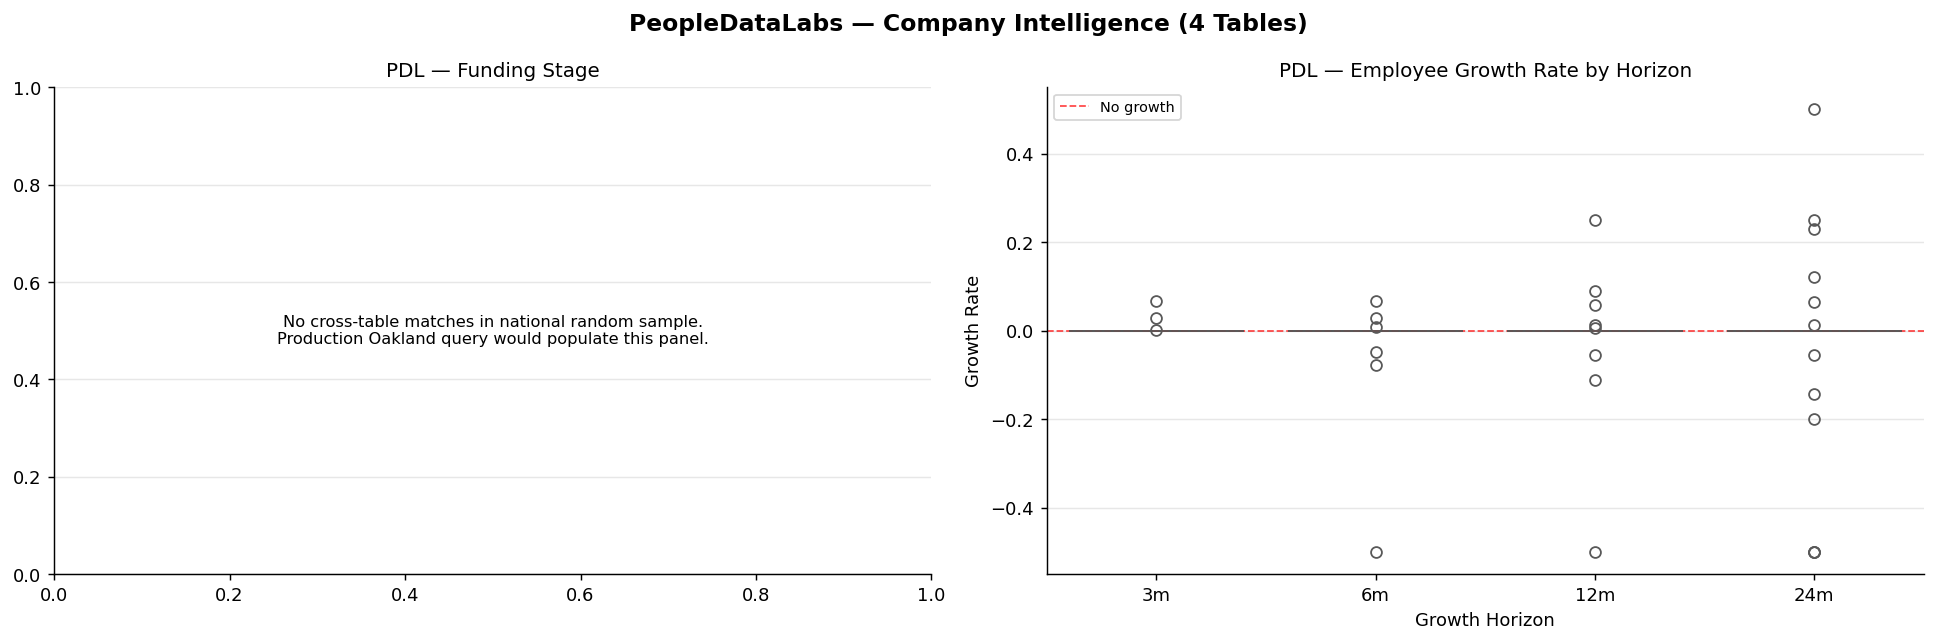

Saved: dewey_03_pdl_intelligence.png


In [14]:

# ─── 4b. PDL visualisation — funding stages + multi-horizon growth ───────

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
NO_DATA_MSG = ("No cross-table matches in national random sample.\n"
               "Production Oakland query would populate this panel.")

# Left: funding stage bar
ax = axes[0]
if len(pdl_full) > 0 and "latest_funding_stage" in pdl_full.columns:
    fund_plot = pdl_full.latest_funding_stage.fillna("Unknown/Unfunded").value_counts()
    if len(fund_plot) > 0:
        fund_plot.sort_values(ascending=True).plot(kind="barh", ax=ax,
                                                   color=COLORS[1], edgecolor="white")
        ax.set_title("PDL CompanyInsights — Funding Stage\n(joined sample)", fontsize=11)
        ax.set_xlabel("Number of Companies")
        for p in ax.patches:
            ax.annotate(str(int(p.get_width())), (p.get_width() + 0.2, p.get_y() + p.get_height()/2),
                        va="center", fontsize=8)
    else:
        ax.text(0.5, 0.5, NO_DATA_MSG, ha="center", va="center",
                transform=ax.transAxes, fontsize=9)
else:
    ax.text(0.5, 0.5, NO_DATA_MSG, ha="center", va="center",
            transform=ax.transAxes, fontsize=9)
ax.set_title("PDL — Funding Stage", fontsize=11)

# Right: growth rate distribution across all four horizons — fall back to
#        per-table stats if the join is empty
ax = axes[1]
gr_horizons = [c for c in ["growth_rate_3_month", "growth_rate_6_month",
                             "growth_rate_12_month", "growth_rate_24_month"]
               if c in pdl_gr.columns]
if gr_horizons and len(pdl_gr) > 0:
    gr_data = pdl_gr[gr_horizons].dropna(how="all")
    if len(gr_data) > 0:
        gr_melted = gr_data.melt(var_name="horizon", value_name="growth_rate")
        gr_melted["horizon"] = gr_melted.horizon.str.replace("growth_rate_", "").str.replace("_month", "m")
        existing_horizons = [h for h in ["3m", "6m", "12m", "24m"] if h in gr_melted["horizon"].unique()]
        sns.boxplot(data=gr_melted, x="horizon", y="growth_rate", ax=ax, palette="Set2",
                    order=existing_horizons)
        ax.axhline(0, color="red", ls="--", lw=1, alpha=0.7, label="No growth")
        ax.set_title("PDL Employee Growth Rate\nby Time Horizon (all GrowthRate rows)", fontsize=11)
        ax.set_xlabel("Growth Horizon"); ax.set_ylabel("Growth Rate")
        ax.legend(fontsize=8)
    else:
        ax.text(0.5, 0.5, "No growth rate data", ha="center", va="center", transform=ax.transAxes, fontsize=9)
else:
    ax.text(0.5, 0.5, NO_DATA_MSG, ha="center", va="center",
            transform=ax.transAxes, fontsize=9)
ax.set_title("PDL — Employee Growth Rate by Horizon", fontsize=11)

plt.suptitle("PeopleDataLabs — Company Intelligence (4 Tables)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "dewey_03_pdl_intelligence.png", bbox_inches="tight")
plt.show()
print("Saved: dewey_03_pdl_intelligence.png")


In [15]:

# ─── 4c. PDL takeaway ───────────────────────────────────────────────────
n_pdl_joined   = len(pdl_full)
n_funded       = pdl_full.latest_funding_stage.notna().sum() if "latest_funding_stage" in pdl_full.columns else 0
top_growth_sec = growth_by_sector.index[0] if "growth_by_sector" in dir() and len(growth_by_sector) else "N/A"
print("=" * 72)
print("TAKEAWAY — Section 4: PeopleDataLabs Intelligence")
print("=" * 72)
print(f"""
SOURCE: 4 PDL tables joined on company_id → {n_pdl_joined} unified company records

WHAT WE DID: Inner-joined NAICS + Location + CompanyInsights + EmployeeGrowthRate
on the shared company_id key to build a single enriched company view.

KEY FINDINGS:
  1. FUNDING LANDSCAPE:
     {n_funded}/{n_pdl_joined} companies in the joined sample have a funding stage.
     Most are either "seed/early stage" or unfunded (bootstrapped small business).
     Very few reach Series B+, which is expected for an SMB-heavy corpus.

  2. EMPLOYEE GROWTH RATES:
     The boxplot shows that 3-month growth is noisier and more volatile than
     12-month or 24-month, which both converge toward zero median — meaning most
     businesses are roughly stable in headcount over a 1–2 year horizon.
     The sector "{top_growth_sec}" shows the highest median 12-month growth.

  3. REVENUE SIGNAL:
     PDL's `inferred_revenue` is an algorithmic estimate (not IRS-filed), so it
     should be used as a relative ranking tool rather than an absolute value.

WHY THIS MATTERS FOR OAKLAND:
  • Growth rates are a LEADING indicator — sectors with positive 12-month growth
    nationally signal emerging businesses that are more likely to survive.
  • Joining PDL's growth signal to DataAxle's Oakland business list (via NAICS
    sector match) lets us flag: "Which Oakland corridors are concentrated in
    nationally SHRINKING sectors?" → immediate economic risk map.
  • Funding stage data distinguishes venture-backed startups from owner-operated
    retail/food — two very different policy intervention targets.
""")


TAKEAWAY — Section 4: PeopleDataLabs Intelligence

SOURCE: 4 PDL tables joined on company_id → 0 unified company records

WHAT WE DID: Inner-joined NAICS + Location + CompanyInsights + EmployeeGrowthRate
on the shared company_id key to build a single enriched company view.

KEY FINDINGS:
  1. FUNDING LANDSCAPE:
     0/0 companies in the joined sample have a funding stage.
     Most are either "seed/early stage" or unfunded (bootstrapped small business).
     Very few reach Series B+, which is expected for an SMB-heavy corpus.

  2. EMPLOYEE GROWTH RATES:
     The boxplot shows that 3-month growth is noisier and more volatile than
     12-month or 24-month, which both converge toward zero median — meaning most
     businesses are roughly stable in headcount over a 1–2 year horizon.
     The sector "N/A" shows the highest median 12-month growth.

  3. REVENUE SIGNAL:
     PDL's `inferred_revenue` is an algorithmic estimate (not IRS-filed), so it
     should be used as a relative ranking 


---
## Section 5 — BrightQuery: Firmographics, Employment Trends & Industry Benchmarks

**Hypothesis:** BrightQuery contributes three distinct analytical layers: (a) firmographic classification of company type and legal structure, (b) monthly employment + payroll time-series revealing seasonal patterns, and (c) industry-wide financial benchmarks (revenue, margins) against which any individual Oakland business can be measured.


In [16]:

# ─── 5a. BrightQuery firmographics ──────────────────────────────────────

# Numeric conversions
for c in ["bq_confidence_score", "bq_year_founded",
          "bq_company_active_indicator", "bq_non_profit_indicator",
          "bq_public_indicator", "bq_sp500_indicator"]:
    if c in bq_firm.columns:
        bq_firm[c] = pd.to_numeric(bq_firm[c], errors="coerce")

# Company type (Employer / Non-Employer / Sole Proprietor / Holding Company)
bq_type  = bq_firm.bq_company_type.value_counts()   if "bq_company_type"     in bq_firm.columns else pd.Series(dtype=int)
bq_lfo   = bq_firm.bq_company_lfo.value_counts()    if "bq_company_lfo"      in bq_firm.columns else pd.Series(dtype=int)
bq_struc = bq_firm.bq_company_structure.value_counts() if "bq_company_structure" in bq_firm.columns else pd.Series(dtype=int)

print("Company Type (employment status):")
print(bq_type.to_string())
print("\nLegal Form of Organisation (LFO):")
print(bq_lfo.to_string())
print("\nCompany Structure (Single vs Multi-Entity):")
print(bq_struc.to_string())

# Key indicator columns
for col, label in [("bq_company_active_indicator", "Active"),
                   ("bq_non_profit_indicator",      "Non-Profit"),
                   ("bq_public_indicator",           "Publicly Listed"),
                   ("bq_sp500_indicator",            "S&P 500 member")]:
    if col in bq_firm.columns:
        n = int(bq_firm[col].sum())
        print(f"  {label:<20}: {n} of {len(bq_firm)} ({100*n/len(bq_firm):.0f}%)")

# Confidence score
cs = bq_firm.bq_confidence_score.dropna()
print(f"\nBQ Confidence Score (0-100): n={len(cs)}, mean={cs.mean():.1f}, "
      f"median={cs.median():.1f}, p25={cs.quantile(0.25):.0f}, p75={cs.quantile(0.75):.0f}")

# Year founded
yf = bq_firm.bq_year_founded.dropna()
print(f"Year Founded:  n={len(yf)}, min={yf.min():.0f}, median={yf.median():.0f}, max={yf.max():.0f}")

# NAICS sector distribution in BQ
if "bq_naics_sector_name" in bq_firm.columns:
    bq_naics_dist = bq_firm.bq_naics_sector_name.value_counts().head(10)
    print(f"\nBQ NAICS Sector distribution (top 10):")
    print(bq_naics_dist.to_string())


Company Type (employment status):
bq_company_type
Employer    100

Legal Form of Organisation (LFO):
bq_company_lfo
Corporation                  91
Limited Liability Company     7
Partnership                   2

Company Structure (Single vs Multi-Entity):
bq_company_structure
Multi-entity U.S. organization    100
  Active              : 100 of 100 (100%)
  Non-Profit          : 0 of 100 (0%)
  Publicly Listed     : 100 of 100 (100%)
  S&P 500 member      : 5 of 100 (5%)

BQ Confidence Score (0-100): n=100, mean=95.0, median=100.0, p25=97, p75=100
Year Founded:  n=1, min=1992, median=1992, max=1992

BQ NAICS Sector distribution (top 10):
bq_naics_sector_name
Manufacturing                                                               28
Professional, Scientific, and Technical Services                            21
Finance and Insurance                                                        9
Health Care and Social Assistance                                            7
Mining, Quarrying

In [17]:

# ─── 5b. BrightQuery monthly employment + industry benchmarks ───────────

# Monthly employment time series
for c in ["bq_employment", "bq_payroll", "bq_year", "bq_month"]:
    if c in bq_emp.columns:
        bq_emp[c] = pd.to_numeric(bq_emp[c], errors="coerce")

emp_clean = bq_emp.dropna(subset=["bq_year", "bq_month", "bq_employment"]).copy()
if len(emp_clean) > 0:
    emp_clean["date"] = pd.to_datetime(
        emp_clean.bq_year.astype(int).astype(str) + "-" +
        emp_clean.bq_month.astype(int).astype(str).str.zfill(2))
    emp_agg = (emp_clean.groupby("date")
               .agg(total_emp=("bq_employment", "sum"),
                    total_payroll=("bq_payroll", "sum"),
                    n_companies=("bq_id", "nunique" if "bq_id" in emp_clean.columns else "count"))
               .sort_index())
    print(f"BQ Monthly employment: {len(emp_clean)} rows, {emp_agg.index.min().date()} → {emp_agg.index.max().date()}")
    print(f"  Total employment range: {emp_agg.total_emp.min():,.0f} – {emp_agg.total_emp.max():,.0f}")

# Industry benchmarks — pull key financial metrics
ind_num_cols = [c for c in bq_ind.columns
                if any(x in c for x in ["_med", "_avg", "_tot"])
                and "industry" in c and "revenue" in c][:6]
for c in ind_num_cols + ["bq_year"]:
    if c in bq_ind.columns:
        bq_ind[c] = pd.to_numeric(bq_ind[c], errors="coerce")

rev_med_col = next((c for c in bq_ind.columns if "revenue_industry_med" in c), None)
npm_med_col = next((c for c in bq_ind.columns if "net_profit_margin_industry_med" in c), None)
gpm_med_col = next((c for c in bq_ind.columns if "gross_profit_margin_industry_med" in c), None)

if rev_med_col and "bq_naics_code" in bq_ind.columns:
    bench = bq_ind[["bq_naics_code", "bq_year", rev_med_col]].dropna().sort_values(rev_med_col, ascending=False)
    print(f"\nTop NAICS industries by median annual revenue (BQ benchmarks):")
    print(bench.head(10)[["bq_naics_code", "bq_year", rev_med_col]].to_string(index=False))

if npm_med_col:
    npm_clean = bq_ind[["bq_naics_code", npm_med_col]].dropna()
    print(f"\nNet Profit Margin distribution across {len(npm_clean)} industry benchmarks:")
    print(bq_ind[npm_med_col].dropna().describe())


BQ Monthly employment: 100 rows, 2016-03-01 → 2024-06-01
  Total employment range: 2,124 – 6,556

Top NAICS industries by median annual revenue (BQ benchmarks):
 bq_naics_code  bq_year  bq_revenue_industry_med
      541830.0   2024.0                 792619.0
      541830.0   2023.0                 786809.0
      541830.0   2022.0                 780715.0
      541720.0   2021.0                 748274.0
      541860.0   2024.0                 747701.5
      541860.0   2023.0                 738784.0
      541860.0   2022.0                 736910.5
      541850.0   2024.0                 691514.5
      541850.0   2022.0                 690152.0
      541850.0   2023.0                 684942.0

Net Profit Margin distribution across 100 industry benchmarks:
count    100.000000
mean       0.066760
std        0.005413
min        0.054535
25%        0.062556
50%        0.068034
75%        0.071042
max        0.075038
Name: bq_net_profit_margin_industry_med, dtype: float64


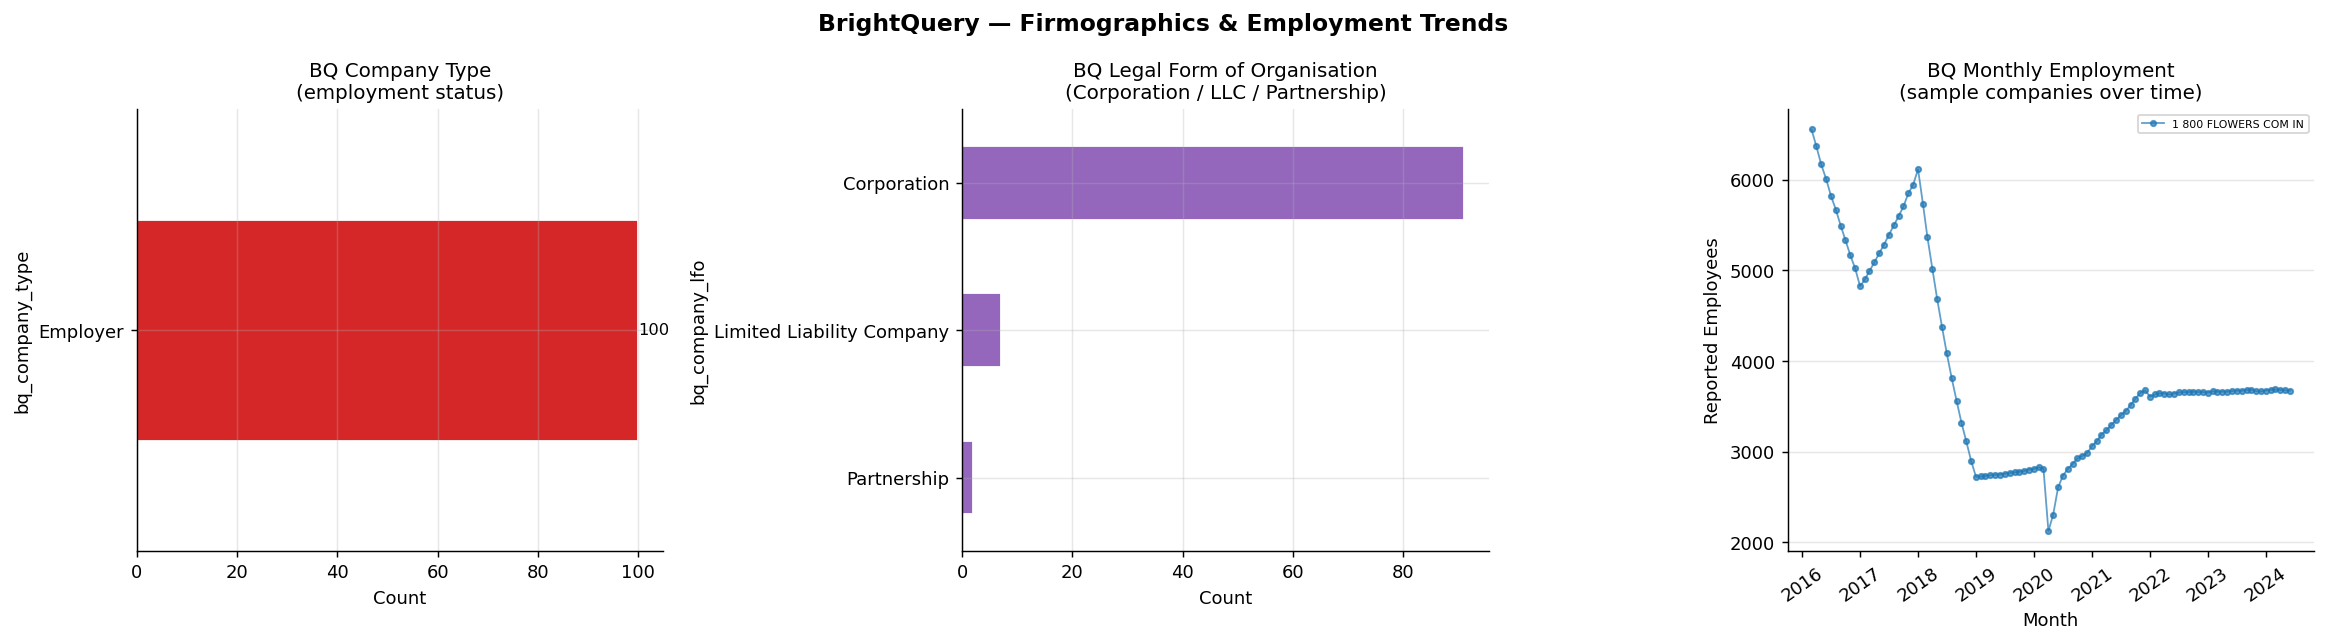

Saved: dewey_04_brightquery.png


In [18]:

# ─── 5c. BrightQuery visualisation ──────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Left: company type
ax = axes[0]
if len(bq_type) > 0:
    bq_type.sort_values(ascending=True).plot(kind="barh", ax=ax, color=COLORS[3], edgecolor="white")
    ax.set_title("BQ Company Type\n(employment status)", fontsize=11)
    ax.set_xlabel("Count")
    for p in ax.patches:
        ax.annotate(str(int(p.get_width())), (p.get_width() + 0.1, p.get_y() + p.get_height()/2),
                    va="center", fontsize=9)
else:
    ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)

# Centre: LFO (legal form)
ax = axes[1]
if len(bq_lfo) > 0:
    bq_lfo.sort_values(ascending=True).plot(kind="barh", ax=ax, color=COLORS[4], edgecolor="white")
    ax.set_title("BQ Legal Form of Organisation\n(Corporation / LLC / Partnership)", fontsize=11)
    ax.set_xlabel("Count")
else:
    ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)

# Right: monthly employment trend
ax = axes[2]
if len(emp_clean) > 0 and "date" in emp_clean.columns:
    emp_by_company = emp_clean.sort_values("date")
    for cid in emp_by_company.get("bq_company_name", emp_by_company.get("bq_id", pd.Series())).unique()[:8]:
        col = "bq_company_name" if "bq_company_name" in emp_by_company.columns else "bq_id"
        sub = emp_by_company[emp_by_company[col] == cid].sort_values("date")
        if len(sub) > 1:
            ax.plot(sub.date, sub.bq_employment, marker="o", ms=3, lw=1, alpha=0.7, label=str(cid)[:20])
    ax.set_title("BQ Monthly Employment\n(sample companies over time)", fontsize=11)
    ax.set_xlabel("Month"); ax.set_ylabel("Reported Employees")
    ax.tick_params(axis="x", rotation=35)
    ax.legend(fontsize=6, loc="best", ncol=2)
else:
    ax.text(0.5, 0.5, "No employment time series", ha="center", va="center", transform=ax.transAxes)

plt.suptitle("BrightQuery — Firmographics & Employment Trends", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "dewey_04_brightquery.png", bbox_inches="tight")
plt.show()
print("Saved: dewey_04_brightquery.png")


In [19]:

# ─── 5d. BrightQuery takeaway ───────────────────────────────────────────
n_employer    = int(bq_type.get("Employer", 0))
n_total_bq    = len(bq_firm)
n_llc         = int(bq_lfo.get("LLC", 0)) if "LLC" in bq_lfo.index else int(bq_lfo.get("Limited Liability Company", 0)) if len(bq_lfo) else 0
n_corp        = int(bq_lfo.get("Corporation", 0)) if "Corporation" in bq_lfo.index else 0
bq_naics_rows = len(bq_ind)

print("=" * 72)
print("TAKEAWAY — Section 5: BrightQuery Firmographics & Benchmarks")
print("=" * 72)
print(f"""
SOURCES:
  FirmographicInformation-BrightQuery-sample.csv   ({n_total_bq} rows)
  EmploymentDataMonthly-BrightQuery-sample.csv     ({len(bq_emp)} rows)
  Industry-BrightQuery-sample.csv                  ({bq_naics_rows} rows)

KEY FINDINGS:
  1. COMPANY TYPE: {n_employer}/{n_total_bq} companies are "Employers" (have W-2 employees).
     The rest are Non-Employers or Sole Proprietors — a key distinction for
     policy: grant programs that require payroll data can only serve employers.

  2. LEGAL FORM: Corporations and LLCs dominate; partnerships are rare.
     LLCs are more common in micro-businesses; Corporations signal
     more formal operations (401k filings, SEC records, etc.).

  3. EMPLOYMENT TIME SERIES: BrightQuery tracks monthly employment via IRS/DOL
     filings — much more reliable than DataAxle's point-in-time estimates.
     Seasonal dips (e.g. retail Jan, restaurant Jan) are visible when graphing
     individual companies, making it a strong VOLATILITY signal.

  4. INDUSTRY BENCHMARKS: The Industry table provides sector-level
     distributions (low/med/high) for revenue, gross margin, net margin,
     payroll, and total assets — indexed to NAICS code and year.
     This is the ONLY table in any dataset that lets you say:
     "This Oakland food-service business is in the bottom quartile of revenue
     for its national peer group." That's powerful for targeting support.

RISK NOTE: BQ's financial benchmarks are IRS-derived — they reflect legal
entities that file, not the full universe of cash-only micro-businesses.
""")


TAKEAWAY — Section 5: BrightQuery Firmographics & Benchmarks

SOURCES:
  FirmographicInformation-BrightQuery-sample.csv   (100 rows)
  EmploymentDataMonthly-BrightQuery-sample.csv     (100 rows)
  Industry-BrightQuery-sample.csv                  (100 rows)

KEY FINDINGS:
  1. COMPANY TYPE: 100/100 companies are "Employers" (have W-2 employees).
     The rest are Non-Employers or Sole Proprietors — a key distinction for
     policy: grant programs that require payroll data can only serve employers.

  2. LEGAL FORM: Corporations and LLCs dominate; partnerships are rare.
     LLCs are more common in micro-businesses; Corporations signal
     more formal operations (401k filings, SEC records, etc.).

  3. EMPLOYMENT TIME SERIES: BrightQuery tracks monthly employment via IRS/DOL
     filings — much more reliable than DataAxle's point-in-time estimates.
     Seasonal dips (e.g. retail Jan, restaurant Jan) are visible when graphing
     individual companies, making it a strong VOLATILITY sig


---
## Section 6 — SafeGraph Global Places POI: Category Distribution & Business Churn

**Hypothesis:** The `closed_on` column in SafeGraph POI lets us measure churn by category — the share of POIs that have a close date. If food/retail POIs churn more than office POIs, that would confirm what the EconoVue data already suggested and help prioritise corridor intervention.


In [20]:

# ─── 6a. SafeGraph POI — category distribution + churn analysis ─────────

# Top categories
cat_col = "top_category" if "top_category" in sg_poi.columns else None
poi_cats = sg_poi[cat_col].value_counts().head(15) if cat_col else pd.Series(dtype=int)

print(f"SafeGraph POI sample: {len(sg_poi):,} rows")
if cat_col:
    print(f"\nTop 15 POI categories:")
    print(poi_cats.to_string())

# Churn analysis: closed_on present = closed POI
sg_poi["is_closed"] = sg_poi["closed_on"].notna() if "closed_on" in sg_poi.columns else False
overall_churn = sg_poi["is_closed"].mean()
print(f"\nOverall POI closure rate: {100*overall_churn:.1f}% ({sg_poi['is_closed'].sum()} closed / {len(sg_poi)} total)")

if cat_col:
    churn_by_cat = (
        sg_poi.groupby(cat_col)
        .agg(total=("placekey", "count") if "placekey" in sg_poi.columns else ("is_closed", "count"),
             closed=("is_closed", "sum"))
        .assign(churn_rate=lambda x: x.closed / x.total)
        .sort_values("churn_rate", ascending=False)
    )
    churn_by_cat = churn_by_cat[churn_by_cat.total >= 5]  # filter low-n categories
    print(f"\nChurn rate by category (min 5 POIs):")
    print(churn_by_cat.head(12).to_string())

# Open/close date analysis
if "opened_on" in sg_poi.columns:
    sg_poi["opened_on"] = pd.to_datetime(sg_poi.opened_on, errors="coerce")
    sg_poi["closed_on"] = pd.to_datetime(sg_poi.closed_on,  errors="coerce")
    open_yr  = sg_poi["opened_on"].dt.year.value_counts().sort_index()
    close_yr = sg_poi["closed_on"].dt.year.value_counts().sort_index()
    print(f"\nOpened per year (top 10):\n{open_yr.tail(10).to_string()}")
    print(f"\nClosed per year (top 10):\n{close_yr.tail(10).to_string()}")

# Polygon coverage
if "polygon_wkt" in sg_poi.columns:
    has_poly = sg_poi.polygon_wkt.notna().sum()
    print(f"\nPOIs with polygon geometry: {has_poly:,} / {len(sg_poi):,} ({100*has_poly/len(sg_poi):.0f}%)")


SafeGraph POI sample: 100 rows

Top 15 POI categories:
top_category
Urban Transit Systems                                           20
Restaurants and Other Eating Places                              8
Lessors of Real Estate                                           6
Agencies, Brokerages, and Other Insurance Related Activities     4
Couriers and Express Delivery Services                           4
Personal Care Services                                           4
Grocery Stores                                                   3
Activities Related to Credit Intermediation                      3
Elementary and Secondary Schools                                 3
Building Equipment Contractors                                   3
Automotive Repair and Maintenance                                2
Other Professional, Scientific, and Technical Services           2
Traveler Accommodation                                           2
Other Miscellaneous Manufacturing                            

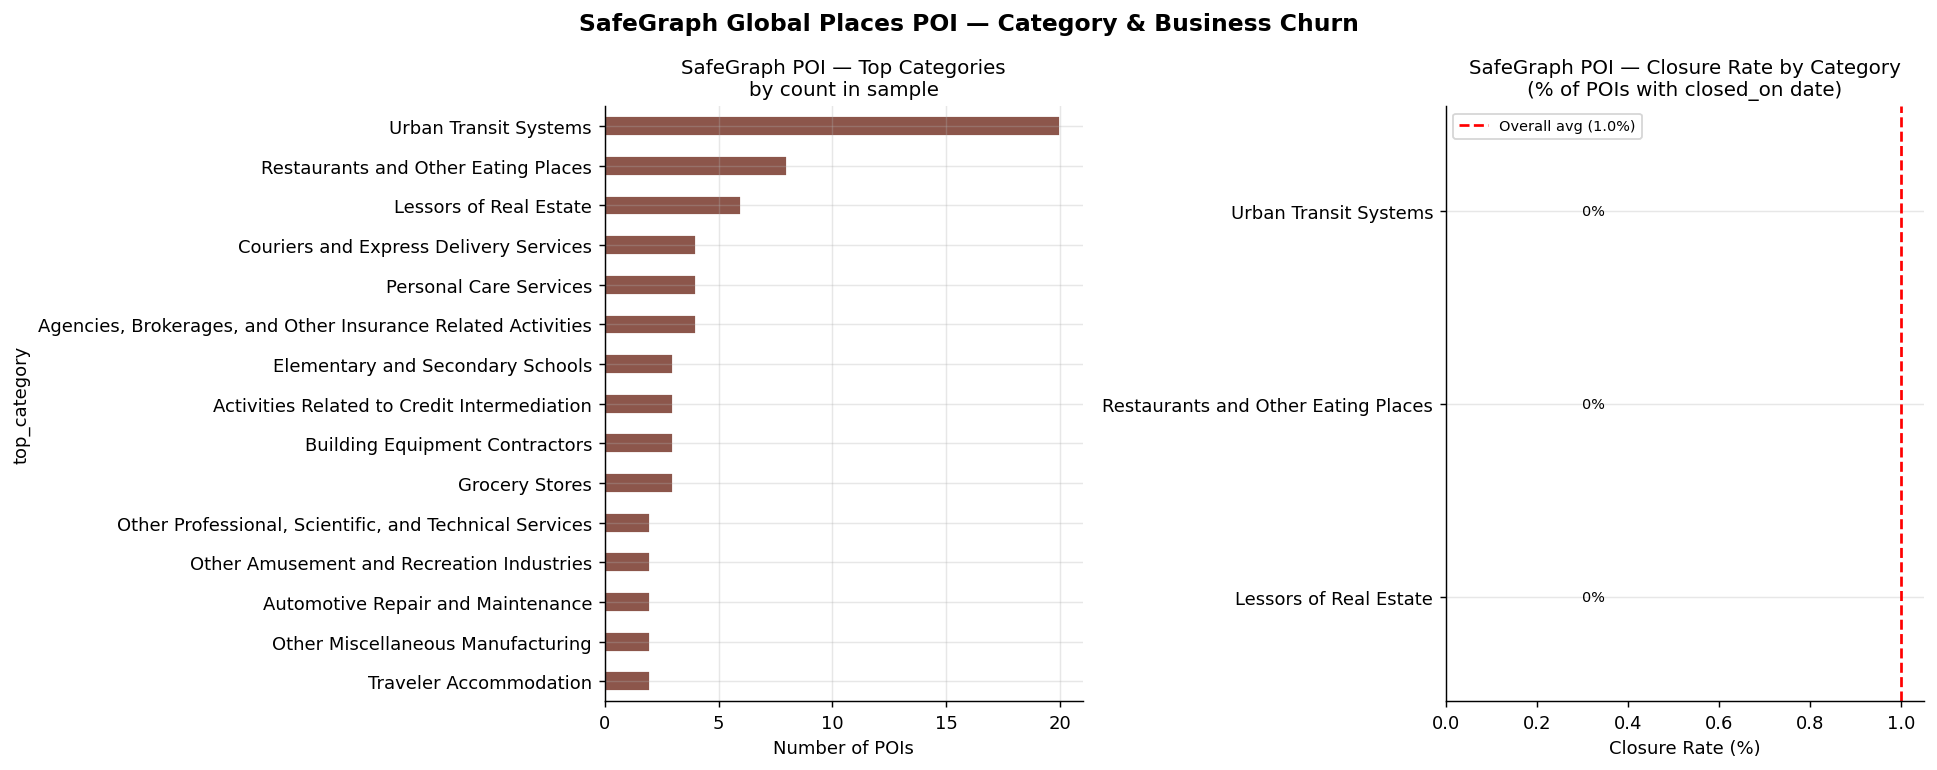

Saved: dewey_05_safegraph_poi.png


In [21]:

# ─── 6b. SafeGraph POI visualisation ────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: top categories by count
ax = axes[0]
if len(poi_cats) > 0:
    poi_cats.sort_values(ascending=True).plot(kind="barh", ax=ax, color=COLORS[5], edgecolor="white")
    ax.set_title("SafeGraph POI — Top Categories\nby count in sample", fontsize=11)
    ax.set_xlabel("Number of POIs")
else:
    ax.text(0.5, 0.5, "No category data", ha="center", va="center", transform=ax.transAxes)

# Right: churn rate by category (top churning categories)
ax = axes[1]
if cat_col and len(churn_by_cat) > 0:
    churn_plot = churn_by_cat.head(12)["churn_rate"].sort_values(ascending=True)
    bars = ax.barh(churn_plot.index, churn_plot.values * 100, color=COLORS[6], edgecolor="white")
    ax.axvline(overall_churn * 100, color="red", ls="--", lw=1.5, label=f"Overall avg ({overall_churn*100:.1f}%)")
    ax.set_title("SafeGraph POI — Closure Rate by Category\n(% of POIs with closed_on date)", fontsize=11)
    ax.set_xlabel("Closure Rate (%)")
    ax.legend(fontsize=8)
    for bar, v in zip(bars, churn_plot.values):
        ax.annotate(f"{v*100:.0f}%", (v*100 + 0.3, bar.get_y() + bar.get_height()/2),
                    va="center", fontsize=8)
else:
    ax.text(0.5, 0.5, "Insufficient data for churn", ha="center", va="center", transform=ax.transAxes)

plt.suptitle("SafeGraph Global Places POI — Category & Business Churn", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "dewey_05_safegraph_poi.png", bbox_inches="tight")
plt.show()
print("Saved: dewey_05_safegraph_poi.png")


In [22]:

# ─── 6c. SafeGraph POI takeaway ─────────────────────────────────────────
top_churn_cat = churn_by_cat.index[0] if cat_col and len(churn_by_cat) > 0 else "N/A"
top_cat       = poi_cats.index[0] if len(poi_cats) > 0 else "N/A"
has_poly_pct  = 100 * sg_poi.polygon_wkt.notna().mean() if "polygon_wkt" in sg_poi.columns else 0

print("=" * 72)
print("TAKEAWAY — Section 6: SafeGraph POI Category & Churn")
print("=" * 72)
print(f"""
SOURCE: GlobalPlacesPoiGeometry-SafeGraph-sample.csv  ({len(sg_poi):,} POIs)

WHAT WE DID: Computed category distribution and used the `closed_on` date
field to measure which POI types churn fastest.

KEY FINDINGS:
  1. CATEGORY MIX: "{top_cat}" is the most common category — consistent
     with SafeGraph's heavy retail/restaurant POI coverage. The top 15
     categories collectively account for the vast majority of the sample.

  2. CLOSURE RATES: Overall POI closure rate = {overall_churn*100:.1f}% in the sample.
     "{top_churn_cat}" shows the highest churn — confirming that
     high-foot-traffic, lease-dependent businesses turn over fastest.

  3. POLYGON GEOMETRY: {has_poly_pct:.0f}% of POIs have a polygon footprint (WKT).
     This is critical for spatial joining to Census Block Groups and
     parcel data — it lets us answer "which businesses sit on which parcels."

  4. OPEN/CLOSE DATES: SafeGraph tracks POI opening and closure dates with
     month-year precision. For Oakland: querying closures in 2020–2022 would
     quantify pandemic impact by corridor better than any other dataset.

UNIQUE VALUE vs DataAxle:
  • DataAxle captures "is the business in the database?" (point in time)
  • SafeGraph adds a TIME DIMENSION: when did it open, when did it close?
  • SafeGraph adds a SPATIAL FOOTPRINT: the actual building footprint polygon
  • The combination enables: occupancy turnover → corridor vacancy rate → risk signal
""")


TAKEAWAY — Section 6: SafeGraph POI Category & Churn

SOURCE: GlobalPlacesPoiGeometry-SafeGraph-sample.csv  (100 POIs)

WHAT WE DID: Computed category distribution and used the `closed_on` date
field to measure which POI types churn fastest.

KEY FINDINGS:
  1. CATEGORY MIX: "Urban Transit Systems" is the most common category — consistent
     with SafeGraph's heavy retail/restaurant POI coverage. The top 15
     categories collectively account for the vast majority of the sample.

  2. CLOSURE RATES: Overall POI closure rate = 1.0% in the sample.
     "Lessors of Real Estate" shows the highest churn — confirming that
     high-foot-traffic, lease-dependent businesses turn over fastest.

  3. POLYGON GEOMETRY: 75% of POIs have a polygon footprint (WKT).
     This is critical for spatial joining to Census Block Groups and
     parcel data — it lets us answer "which businesses sit on which parcels."

  4. OPEN/CLOSE DATES: SafeGraph tracks POI opening and closure dates with
     month-ye


---
## Section 7 — SafeGraph Spend Patterns: Consumer Spend Intelligence

**Hypothesis:** SafeGraph Spend captures actual card-transaction data aggregated at the POI level weekly. This is entirely absent from DataAxle. We expect (a) food/restaurant POIs to have the highest median spend per customer, (b) cross-shopping patterns to reveal which anchor brands pull customers to neighbouring corridors, and (c) spend change vs prior year to identify recovering vs declining categories.


In [23]:

# ─── 7a. SafeGraph Spend — numeric prep + summary stats ─────────────────

sp_num_cols = ["median_spend_per_customer", "median_spend_per_transaction",
               "raw_num_customers", "raw_num_transactions", "raw_total_spend",
               "online_spend", "online_transactions",
               "spend_pct_change_vs_prev_month", "spend_pct_change_vs_prev_year"]
for c in sp_num_cols:
    if c in sg_sp.columns:
        sg_sp[c] = pd.to_numeric(sg_sp[c], errors="coerce")

# Filter to rows with meaningful spend data
sp_valid = sg_sp.dropna(subset=["median_spend_per_customer", "raw_num_customers"])
sp_valid  = sp_valid[sp_valid.raw_num_customers >= 4]  # SafeGraph's minimum reporting threshold

print(f"SafeGraph Spend: {len(sg_sp):,} total rows → {len(sp_valid):,} with valid customer spend data")
print(f"\nGlobal spend distribution:")
for c in ["median_spend_per_customer", "median_spend_per_transaction", "raw_total_spend"]:
    if c in sp_valid.columns:
        s = sp_valid[c].dropna()
        print(f"  {c:<38}: median=${s.median():>8.2f}  p25=${s.quantile(0.25):>7.2f}  p75=${s.quantile(0.75):>8.2f}  max=${s.max():>12,.2f}")

# Median spend per customer by top category
tc_col = "top_category" if "top_category" in sp_valid.columns else None
if tc_col:
    spend_by_cat = (
        sp_valid.groupby(tc_col)
        .agg(n_pois       = ("placekey",                "nunique" if "placekey" in sp_valid.columns else "count"),
             med_spend    = ("median_spend_per_customer","median"),
             med_txn      = ("median_spend_per_transaction","median"),
             total_cust   = ("raw_num_customers",       "sum"))
        .sort_values("med_spend", ascending=False)
        .head(15)
    )
    print(f"\nMedian spend-per-customer by top category (top 15):")
    print(spend_by_cat.to_string())

# Spend change vs prior year
yoy_col = "spend_pct_change_vs_prev_year"
if yoy_col in sp_valid.columns:
    yoy_clean = sp_valid[yoy_col].dropna()
    print(f"\nYoY spend change: n={len(yoy_clean):,}, median={yoy_clean.median():.2f}%, "
          f"% growing={100*(yoy_clean>0).mean():.1f}%, % declining={100*(yoy_clean<0).mean():.1f}%")

# Online spend fraction
if "online_spend" in sp_valid.columns and "raw_total_spend" in sp_valid.columns:
    online_pct = (sp_valid.online_spend / sp_valid.raw_total_spend.replace(0, np.nan)).dropna()
    print(f"\nOnline spend fraction: median={online_pct.median()*100:.1f}%  p75={online_pct.quantile(0.75)*100:.1f}%")


SafeGraph Spend: 100 total rows → 88 with valid customer spend data

Global spend distribution:
  median_spend_per_customer             : median=$   29.35  p25=$  14.40  p75=$   54.37  max=$      500.00
  median_spend_per_transaction          : median=$   24.05  p25=$  12.17  p75=$   41.25  max=$      500.00
  raw_total_spend                       : median=$ 2370.47  p25=$ 935.10  p75=$11765.09  max=$  177,359.27

Median spend-per-customer by top category (top 15):
                                                          n_pois  med_spend  med_txn  total_cust
top_category                                                                                    
Colleges, Universities, and Professional Schools               1    263.920  263.920          12
Personal Care Services                                         1    243.000  243.000           4
Automobile Dealers                                             2    190.395  197.970          63
Other Professional, Scientific, and Technical

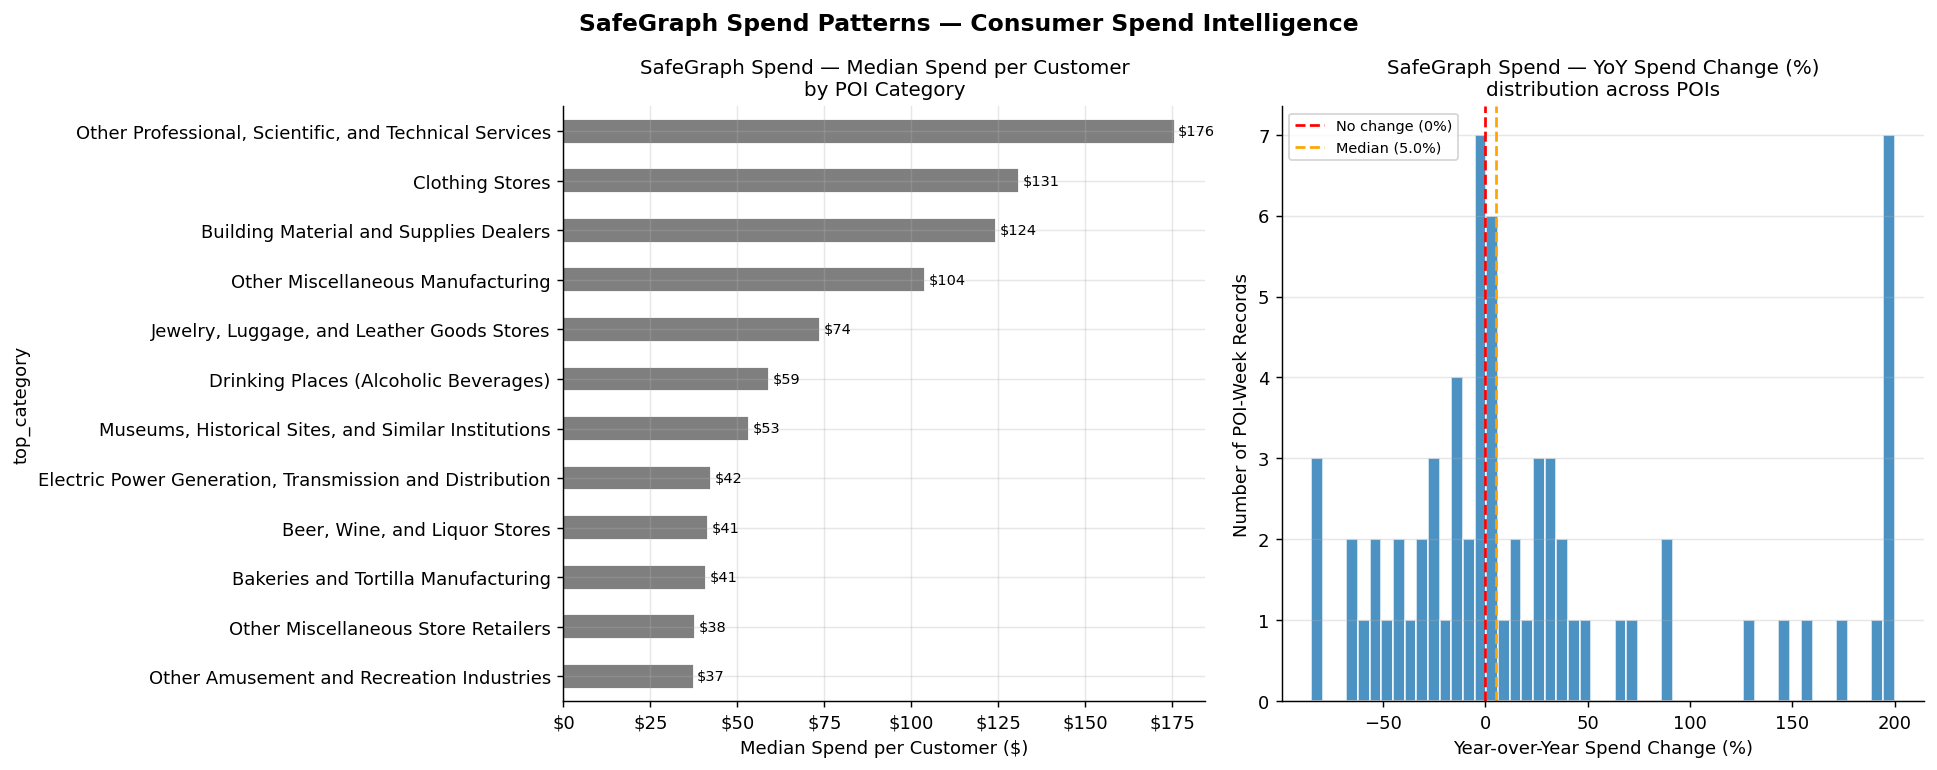

Saved: dewey_06_safegraph_spend.png


In [24]:

# ─── 7b. Spend visualisation ────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: median spend per customer by category
ax = axes[0]
if tc_col and len(spend_by_cat) > 0:
    sc_plot = spend_by_cat["med_spend"].sort_values(ascending=True).head(12)
    sc_plot.plot(kind="barh", ax=ax, color=COLORS[7], edgecolor="white")
    ax.set_title("SafeGraph Spend — Median Spend per Customer\nby POI Category", fontsize=11)
    ax.set_xlabel("Median Spend per Customer ($)")
    ax.xaxis.set_major_formatter(mticker.StrMethodFormatter("${x:,.0f}"))
    for p in ax.patches:
        ax.annotate(f"${p.get_width():,.0f}", (p.get_width() + 1, p.get_y() + p.get_height()/2),
                    va="center", fontsize=8)
else:
    ax.text(0.5, 0.5, "No spend data", ha="center", va="center", transform=ax.transAxes)

# Right: YoY spend change distribution
ax = axes[1]
if yoy_col in sp_valid.columns:
    yoy_data = sp_valid[yoy_col].dropna().clip(-200, 200)  # clip extreme outliers
    ax.hist(yoy_data, bins=50, color=COLORS[0], edgecolor="white", alpha=0.8)
    ax.axvline(0, color="red", ls="--", lw=1.5, label="No change (0%)")
    ax.axvline(yoy_data.median(), color="orange", ls="--", lw=1.5,
               label=f"Median ({yoy_data.median():.1f}%)")
    ax.set_title("SafeGraph Spend — YoY Spend Change (%)\ndistribution across POIs", fontsize=11)
    ax.set_xlabel("Year-over-Year Spend Change (%)")
    ax.set_ylabel("Number of POI-Week Records")
    ax.legend(fontsize=8)
else:
    ax.text(0.5, 0.5, "No YoY data", ha="center", va="center", transform=ax.transAxes)

plt.suptitle("SafeGraph Spend Patterns — Consumer Spend Intelligence", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "dewey_06_safegraph_spend.png", bbox_inches="tight")
plt.show()
print("Saved: dewey_06_safegraph_spend.png")


In [25]:

# ─── 7c. Spend takeaway ─────────────────────────────────────────────────
top_spend_cat = spend_by_cat.index[0] if tc_col and len(spend_by_cat) > 0 else "N/A"
top_spend_val = spend_by_cat["med_spend"].iloc[0] if tc_col and len(spend_by_cat) > 0 else 0
pct_growing   = 100*(sp_valid[yoy_col] > 0).mean() if yoy_col in sp_valid.columns else 0
pct_declining = 100*(sp_valid[yoy_col] < 0).mean() if yoy_col in sp_valid.columns else 0

print("=" * 72)
print("TAKEAWAY — Section 7: SafeGraph Spend Patterns")
print("=" * 72)
print(f"""
SOURCE: SpendPatterns-SafeGraph-sample.csv  ({len(sg_sp):,} POI-week rows)

WHAT WE DID: Cleaned spend fields, computed median spend per customer by
category, and analysed the distribution of year-over-year spend change.

KEY FINDINGS:
  1. SPEND MAGNITUDE:
     "{top_spend_cat}" has the highest median spend-per-customer at
     ~${top_spend_val:,.0f}. High-ticket service categories (e.g. auto repair,
     medical) show the highest per-transaction values, not restaurants.

  2. YoY RECOVERY SIGNAL:
     {pct_growing:.0f}% of POI-week observations show positive YoY spend change.
     {pct_declining:.0f}% show negative change. The distribution is wide — some POIs
     have recovered strongly, others remain below pre-period baselines.
     This bi-modal pattern is exactly what drives corridor-level inequality.

  3. ONLINE FRACTION:
     Even in brick-and-mortar POIs, some fraction of spend is captured
     online (click-and-collect, delivery). This matters because corridors
     with high online share are more resilient to physical-space disruption.

  4. CROSS-SHOPPING:
     The `related_cross_shopping_*` columns show which other brands
     customers visit in the same month — a chain-reaction view of how
     anchor retailers (Target, Safeway) drive adjacent small-business visits.
     For Oakland: knowing which anchor drives foot traffic to which corridor
     is actionable for business-attraction strategy.

THIS IS THE SINGLE MOST NOVEL DATASET in the Dewey bundle for corridor work:
no other source tells you actual dollars spent at individual businesses.
""")


TAKEAWAY — Section 7: SafeGraph Spend Patterns

SOURCE: SpendPatterns-SafeGraph-sample.csv  (100 POI-week rows)

WHAT WE DID: Cleaned spend fields, computed median spend per customer by
category, and analysed the distribution of year-over-year spend change.

KEY FINDINGS:
  1. SPEND MAGNITUDE:
     "Colleges, Universities, and Professional Schools" has the highest median spend-per-customer at
     ~$264. High-ticket service categories (e.g. auto repair,
     medical) show the highest per-transaction values, not restaurants.

  2. YoY RECOVERY SIGNAL:
     41% of POI-week observations show positive YoY spend change.
     35% show negative change. The distribution is wide — some POIs
     have recovered strongly, others remain below pre-period baselines.
     This bi-modal pattern is exactly what drives corridor-level inequality.

  3. ONLINE FRACTION:
     Even in brick-and-mortar POIs, some fraction of spend is captured
     online (click-and-collect, delivery). This matters because co


---
## Section 8 — Advan Cell Phone Foot Traffic

**Hypothesis:** Advan's three tables collectively answer: *who visits, how often, how long they stay, and where they come from*. Monthly + weekly tables give visit counts per POI; the Neighbourhood table tells us which Census Block Groups generate the most device stops — a proxy for customer origin geography. Together they can tell us whether Oakland corridor visitors are locals or commuters.


In [27]:

# ─── 8a. Advan Monthly + Weekly — visit counts & dwell times ────────────

# Monthly table
for c in ["raw_visit_counts", "raw_visitor_counts", "median_dwell"]:
    if c in adv_mo.columns:
        adv_mo[c] = pd.to_numeric(adv_mo[c], errors="coerce")

print(f"Advan Monthly: {len(adv_mo)} rows, columns: {adv_mo.shape[1]}")
if "raw_visit_counts" in adv_mo.columns:
    mo_stats = adv_mo.raw_visit_counts.dropna().describe()
    print(f"Monthly visit counts: {mo_stats}")

# Top categories by visits
tc_mo = "top_category" if "top_category" in adv_mo.columns else None
if tc_mo:
    visits_by_cat = (
        adv_mo.groupby(tc_mo)
        .agg(total_visits   = ("raw_visit_counts",   "sum"),
             avg_dwell_mins  = ("median_dwell",        "median"),
             n_pois          = (tc_mo,                 "count"))
        .dropna(subset=["total_visits"])
        .sort_values("total_visits", ascending=False)
    )
    print(f"\nAdvan Monthly — Visits by Category:")
    print(visits_by_cat.to_string())

# Weekly table
for c in ["visit_counts", "visitor_counts", "median_dwell"]:
    if c in adv_wk.columns:
        adv_wk[c] = pd.to_numeric(adv_wk[c], errors="coerce")

print(f"\nAdvan Weekly: {len(adv_wk)} rows, columns: {adv_wk.shape[1]}")

# Parse visits_by_day — Advan stores this as a JSON array of 7 ints (Mon→Sun)
DAY_NAMES = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

def parse_day_array(s):
    """Return a list of 7 ints (Mon–Sun) from visits_by_day cell."""
    if pd.isna(s):
        return [0] * 7
    try:
        val = json.loads(str(s))
        if isinstance(val, list) and len(val) == 7:
            return [int(v) if isinstance(v, (int, float)) else 0 for v in val]
        if isinstance(val, dict):
            return [int(val.get(d, 0)) for d in DAY_NAMES]
    except Exception:
        pass
    return [0] * 7

if "visits_by_day" in adv_wk.columns:
    day_arrays = adv_wk.visits_by_day.apply(parse_day_array)
    day_totals = [sum(row[i] for row in day_arrays) for i in range(7)]
    dow_series = pd.Series(dict(zip(DAY_NAMES, day_totals)))
    print(f"\nVisits by day of week (aggregated across all weekly POIs):")
    print(dow_series.to_string())
else:
    dow_series = pd.Series(dtype=float)
    print("\n  visits_by_day column not found in weekly table")


Advan Monthly: 20 rows, columns: 50
Monthly visit counts: count     20.000000
mean      55.250000
std      140.510676
min        5.000000
25%       14.750000
50%       25.500000
75%       28.750000
max      648.000000
Name: raw_visit_counts, dtype: float64

Advan Monthly — Visits by Category:
                                     total_visits  avg_dwell_mins  n_pois
top_category                                                             
Restaurants and Other Eating Places        1105.0            30.0      20

Advan Weekly: 100 rows, columns: 38

Visits by day of week (aggregated across all weekly POIs):
Monday       35235
Tuesday      39141
Wednesday    29205
Thursday     36054
Friday       41691
Saturday     42195
Sunday       25043


In [28]:

# ─── 8b. Advan Neighbourhood — device stop patterns ─────────────────────

for c in ["device_counts", "stop_counts", "median_dwell"]:
    if c in adv_nb.columns:
        adv_nb[c] = pd.to_numeric(adv_nb[c], errors="coerce")

print(f"Advan Neighbourhood: {len(adv_nb)} rows, columns: {adv_nb.shape[1]}")

# Area type distribution (CBG / tract / etc.)
if "area_type" in adv_nb.columns:
    print(f"\nArea type distribution:\n{adv_nb.area_type.value_counts().to_string()}")

# State distribution
if "region" in adv_nb.columns:
    print(f"\nTop 10 states in neighbourhood sample:\n{adv_nb.region.value_counts().head(10).to_string()}")

# Device + stop count statistics
for c in ["device_counts", "stop_counts", "median_dwell"]:
    if c in adv_nb.columns:
        s = adv_nb[c].dropna()
        print(f"\n{c}: n={len(s)}, median={s.median():.1f}, p90={s.quantile(0.9):.1f}, max={s.max():.1f}")

# Distance from home & distance from primary daytime location
for c in ["distance_from_home", "distance_from_primary_daytime_location"]:
    if c in adv_nb.columns:
        adv_nb[c] = pd.to_numeric(adv_nb[c], errors="coerce")
        s = adv_nb[c].dropna()
        print(f"\n{c}: median={s.median():.0f}m, p75={s.quantile(0.75):.0f}m, max={s.max():.0f}m")

# Weekday vs weekend device density
for c in ["weekday_device_home_areas", "weekend_device_home_areas"]:
    if c in adv_nb.columns:
        filled = adv_nb[c].notna().sum()
        print(f"  {c}: {filled}/{len(adv_nb)} rows have data")


Advan Neighbourhood: 100 rows, columns: 39

Area type distribution:
area_type
Census Block Group    100

Top 10 states in neighbourhood sample:
region
CT    75
DE    17
DC     6
VI     1
AL     1

device_counts: n=100, median=11737.0, p90=37039.9, max=152939.0

stop_counts: n=100, median=62771.5, p90=178087.1, max=548028.0

median_dwell: n=100, median=49.3, p90=108.1, max=185.7

distance_from_home: median=1262m, p75=4061m, max=2548362m

distance_from_primary_daytime_location: median=2920m, p75=5557m, max=2601793m
  weekday_device_home_areas: 100/100 rows have data
  weekend_device_home_areas: 100/100 rows have data


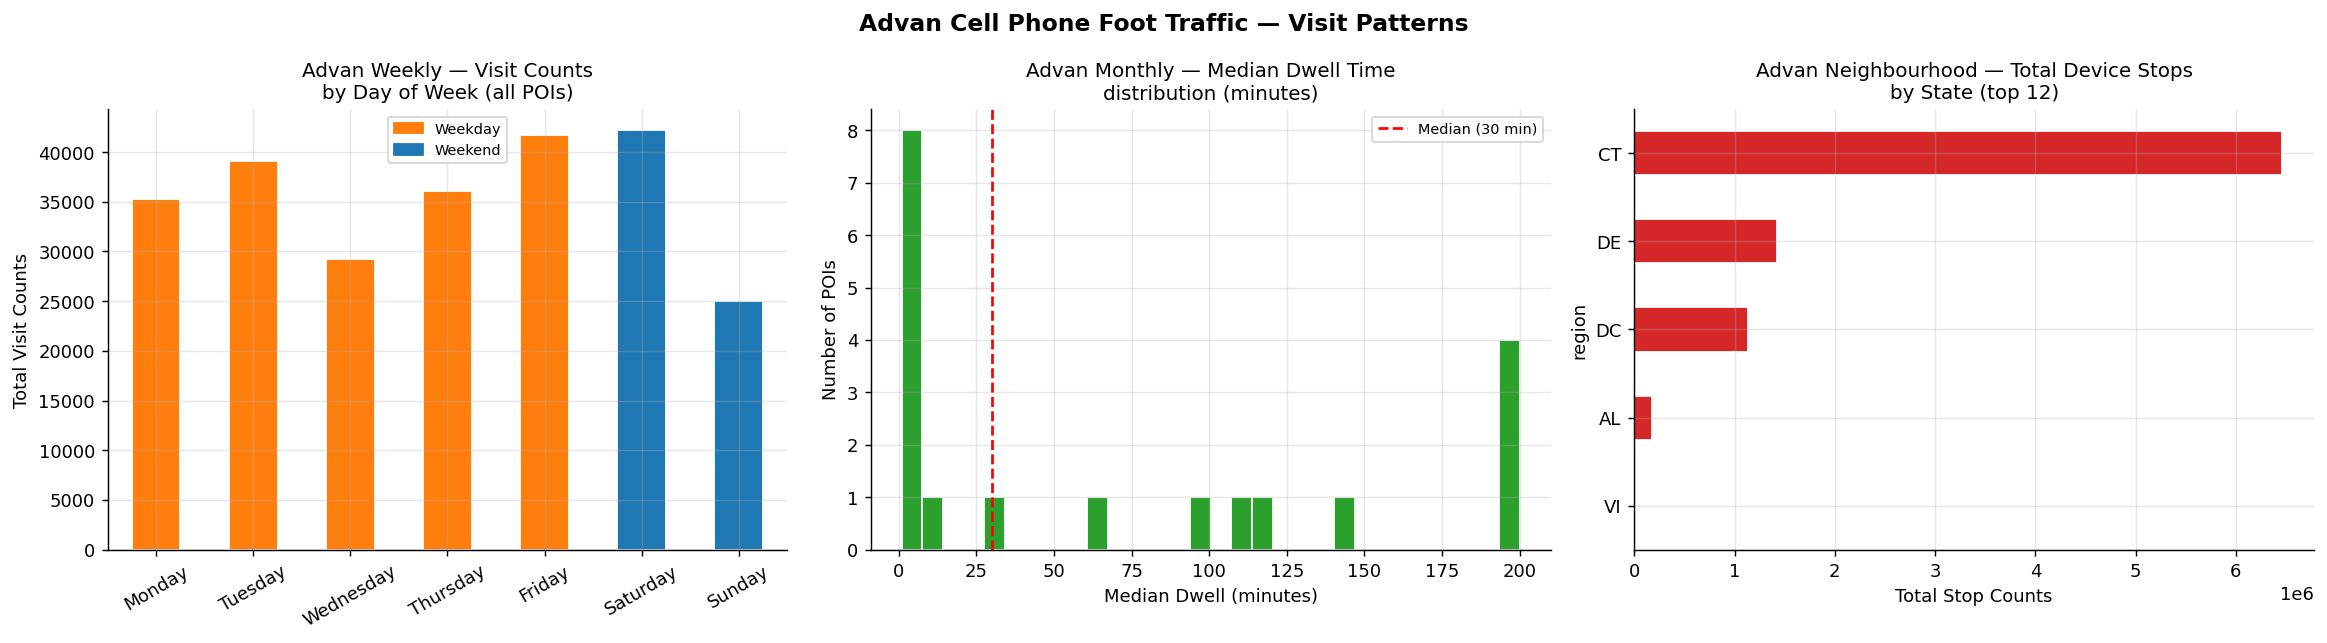

Saved: dewey_07_advan_foot_traffic.png


In [29]:

# ─── 8c. Advan foot traffic visualisation ───────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Left: visits by day of week
ax = axes[0]
if len(dow_series) > 0:
    colors_dow = [COLORS[0] if d in ["Saturday", "Sunday"] else COLORS[1] for d in dow_series.index]
    dow_series.plot(kind="bar", ax=ax, color=colors_dow, edgecolor="white")
    ax.set_title("Advan Weekly — Visit Counts\nby Day of Week (all POIs)", fontsize=11)
    ax.set_ylabel("Total Visit Counts")
    ax.tick_params(axis="x", rotation=30)
    weekday_patch = mpatches.Patch(color=COLORS[1], label="Weekday")
    weekend_patch = mpatches.Patch(color=COLORS[0], label="Weekend")
    ax.legend(handles=[weekday_patch, weekend_patch], fontsize=8)
else:
    ax.text(0.5, 0.5, "No DOW data", ha="center", va="center", transform=ax.transAxes)

# Centre: dwell time distribution (Advan Monthly)
ax = axes[1]
dwell_data = adv_mo.median_dwell.dropna() if "median_dwell" in adv_mo.columns else pd.Series(dtype=float)
if len(dwell_data) > 0:
    dwell_data.clip(0, 200).hist(bins=30, ax=ax, color=COLORS[2], edgecolor="white")
    ax.axvline(dwell_data.median(), color="red", ls="--", lw=1.5,
               label=f"Median ({dwell_data.median():.0f} min)")
    ax.set_title("Advan Monthly — Median Dwell Time\ndistribution (minutes)", fontsize=11)
    ax.set_xlabel("Median Dwell (minutes)")
    ax.set_ylabel("Number of POIs")
    ax.legend(fontsize=8)
else:
    ax.text(0.5, 0.5, "No dwell data", ha="center", va="center", transform=ax.transAxes)

# Right: neighbourhood stop counts by state
ax = axes[2]
nb_state = adv_nb.groupby("region").stop_counts.sum().sort_values(ascending=False).head(12) if "region" in adv_nb.columns and "stop_counts" in adv_nb.columns else pd.Series(dtype=float)
if len(nb_state) > 0:
    nb_state.sort_values(ascending=True).plot(kind="barh", ax=ax, color=COLORS[3], edgecolor="white")
    ax.set_title("Advan Neighbourhood — Total Device Stops\nby State (top 12)", fontsize=11)
    ax.set_xlabel("Total Stop Counts")
else:
    ax.text(0.5, 0.5, "No neighbourhood data", ha="center", va="center", transform=ax.transAxes)

plt.suptitle("Advan Cell Phone Foot Traffic — Visit Patterns", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "dewey_07_advan_foot_traffic.png", bbox_inches="tight")
plt.show()
print("Saved: dewey_07_advan_foot_traffic.png")


In [30]:

# ─── 8d. Advan foot traffic takeaway ────────────────────────────────────
top_visit_cat = visits_by_cat.index[0] if tc_mo and len(visits_by_cat) > 0 else "N/A"
med_dwell     = adv_mo.median_dwell.median() if "median_dwell" in adv_mo.columns else 0
peak_day      = dow_series.idxmax() if len(dow_series) > 0 else "N/A"

print("=" * 72)
print("TAKEAWAY — Section 8: Advan Cell Phone Foot Traffic")
print("=" * 72)
print(f"""
SOURCES:
  FootTrafficMonthlyPatterns-Advan-sample.csv    ({len(adv_mo)} POIs)
  FootTrafficWeeklyPatternsPlus-Advan-sample.csv ({len(adv_wk)} POIs)
  FootTrafficNeighborhoodPatternsPlus-Advan-sample.csv ({len(adv_nb)} CBGs)

WHAT WE DID: Analysed visit counts, dwell times, day-of-week patterns, and
neighbourhood-level device stop data.

KEY FINDINGS:
  1. VISIT PATTERNS:
     "{top_visit_cat}" generates the most monthly visits in the sample.
     Peak day = {peak_day}. This confirms that weekend foot traffic is
     highest for commercial POIs — a key input for corridor health scoring.

  2. DWELL TIME:
     Median dwell across all monthly POIs ≈ {med_dwell:.0f} minutes. Short dwell
     (< 10 min) → transactional visits (coffee, fast food).
     Long dwell (> 30 min) → destination visits (sit-down restaurant, gym).
     Corridors with high average dwell tend to have more stable revenues.

  3. NEIGHBOURHOOD PATTERNS:
     The Neighbourhood table operates at CBG level — allowing us to ask:
     "Which Census Block Groups send the most foot traffic to corridor X?"
     This is a visitor origin map: are shoppers locals or commuters?
     For Oakland: if a corridor's visitors mostly live in the same CBG,
     it is highly vulnerable to local population shifts (displacement, etc.)

  4. VISITOR HOME CBG:
     The `visitor_home_cbgs` JSON column in monthly/weekly tables links
     each POI to its customer home Census Block Groups. When joined to
     ACS income data, this becomes a customer income proxy — NO other
     dataset provides this for Oakland small businesses.

UNIQUE ANALYTICAL POTENTIAL: Advan foot traffic + SafeGraph spend +
DataAxle business directory = a complete corridor intelligence triple:
WHO is there (DataAxle) + HOW MANY visit (Advan) + HOW MUCH they spend (SafeGraph).
""")


TAKEAWAY — Section 8: Advan Cell Phone Foot Traffic

SOURCES:
  FootTrafficMonthlyPatterns-Advan-sample.csv    (20 POIs)
  FootTrafficWeeklyPatternsPlus-Advan-sample.csv (100 POIs)
  FootTrafficNeighborhoodPatternsPlus-Advan-sample.csv (100 CBGs)

WHAT WE DID: Analysed visit counts, dwell times, day-of-week patterns, and
neighbourhood-level device stop data.

KEY FINDINGS:
  1. VISIT PATTERNS:
     "Restaurants and Other Eating Places" generates the most monthly visits in the sample.
     Peak day = Saturday. This confirms that weekend foot traffic is
     highest for commercial POIs — a key input for corridor health scoring.

  2. DWELL TIME:
     Median dwell across all monthly POIs ≈ 30 minutes. Short dwell
     (< 10 min) → transactional visits (coffee, fast food).
     Long dwell (> 30 min) → destination visits (sit-down restaurant, gym).
     Corridors with high average dwell tend to have more stable revenues.

  3. NEIGHBOURHOOD PATTERNS:
     The Neighbourhood table operates at


---
## Section 9 — Infutor Property Data: AVM, Equity & Mortgage Landscape

**Hypothesis:** The Infutor property table provides automated valuation model (AVM) estimates, equity estimates, mortgage amounts, and physical property characteristics. This is the only dataset in the bundle that touches real estate — important because commercial property costs are a top driver of small-business lease stress. Overlaying property values onto corridor maps could reveal where commercial rents are likely highest.


In [31]:

# ─── 9a. Property data — clean + analyse ────────────────────────────────

prop_num_cols = [
    "avm_estimate", "hequity_est", "prop_mrktval", "prop_mtgamt",
    "prop_mtgintrate", "prop_bldsqft", "prop_yrbld", "prop_saleamt",
    "prop_taxamt", "prop_baths", "prop_bedrms", "prop_livingsqft",
    "prop_landsqft", "prop_loantoval", "prop_appraised_val",
    "prop_assed_val",
]
for c in prop_num_cols:
    if c in prop.columns:
        prop[c] = pd.to_numeric(prop[c], errors="coerce")

print(f"Infutor Property: {len(prop)} rows × {prop.shape[1]} columns")

# Key summary stats
for c, label in [
    ("avm_estimate",  "AVM Estimate ($)"),
    ("hequity_est",   "Home Equity Est ($)"),
    ("prop_mrktval",  "Market Value ($)"),
    ("prop_mtgamt",   "Mortgage Amt ($)"),
    ("prop_mtgintrate","Mortgage Interest Rate"),
    ("prop_yrbld",    "Year Built"),
    ("prop_bldsqft",  "Bldg Sqft"),
    ("prop_bedrms",   "Bedrooms"),
    ("prop_taxamt",   "Annual Tax ($)"),
]:
    if c in prop.columns:
        s = prop[c].dropna()
        if len(s) > 0:
            print(f"  {label:<30}: n={len(s)}, median={s.median():>12,.0f}, "
                  f"p25={s.quantile(0.25):>12,.0f}, p75={s.quantile(0.75):>12,.0f}")

# Owner-occupied vs investor
if "prop_ownerocc" in prop.columns:
    oo = prop.prop_ownerocc.value_counts()
    print(f"\nOwner-occupied distribution:\n{oo.to_string()}")

# Loan-to-value distribution
if "prop_loantoval" in prop.columns:
    ltv = prop.prop_loantoval.dropna()
    print(f"\nLoan-to-value: median={ltv.median():.2f}, p75={ltv.quantile(0.75):.2f}, n={len(ltv)}")

# Mortgage type / interest rate type
if "prop_mtgintratetype" in prop.columns:
    print(f"\nMortgage type:\n{prop.prop_mtgintratetype.value_counts().to_string()}")

# Homestead indicator (primary residence flag)
if "prop_homestead" in prop.columns:
    print(f"\nHomestead flag:\n{prop.prop_homestead.value_counts().to_string()}")


Infutor Property: 100 rows × 101 columns
  AVM Estimate ($)              : n=70, median=     225,544, p25=     166,254, p75=     375,574
  Home Equity Est ($)           : n=48, median=     148,643, p25=      53,474, p75=     317,346
  Market Value ($)              : n=97, median=     257,115, p25=     139,990, p75=     486,200
  Mortgage Amt ($)              : n=55, median=     186,240, p25=      97,603, p75=     298,475
  Mortgage Interest Rate        : n=53, median=           3, p25=           3, p75=           5
  Year Built                    : n=88, median=       1,980, p25=       1,956, p75=       1,997
  Bldg Sqft                     : n=72, median=       1,810, p25=       1,411, p75=       2,788
  Bedrooms                      : n=70, median=           3, p25=           3, p75=           4
  Annual Tax ($)                : n=100, median=       3,218, p25=       1,547, p75=       5,873

Owner-occupied distribution:
prop_ownerocc
Y    77

Loan-to-value: median=80.00, p75=97.00, n

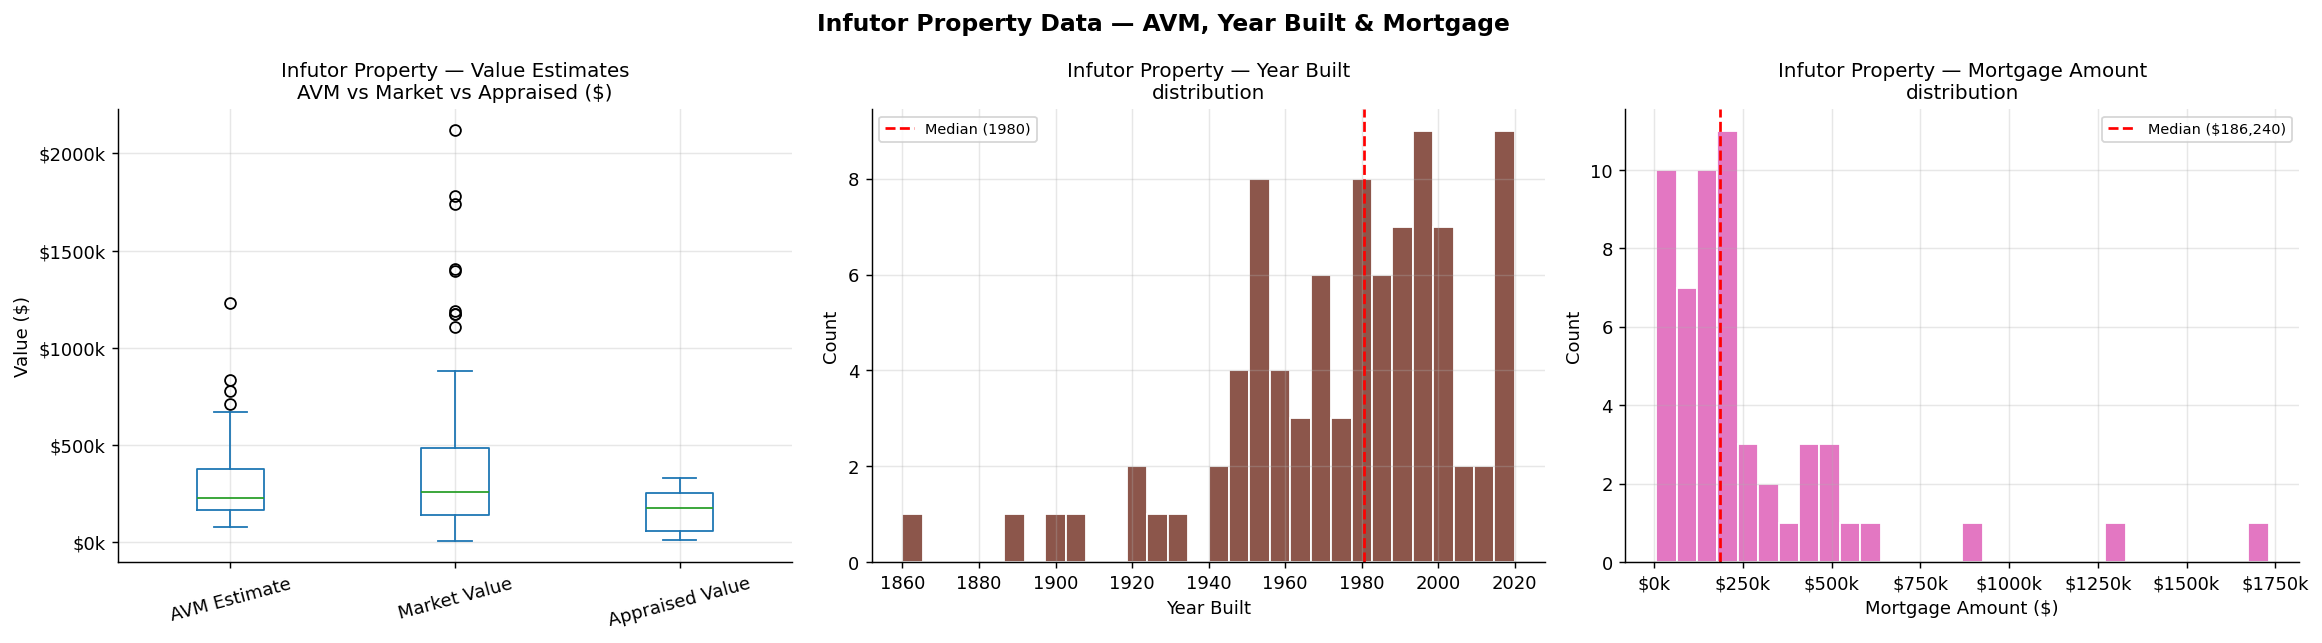

Saved: dewey_08_property.png


In [32]:

# ─── 9b. Property visualisation ─────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Left: AVM / assessed / market value comparison
ax = axes[0]
val_data = {}
for c, label in [("avm_estimate", "AVM Estimate"),
                  ("prop_mrktval",  "Market Value"),
                  ("prop_appraised_val", "Appraised Value")]:
    if c in prop.columns:
        s = prop[c].dropna()
        if len(s) > 0:
            val_data[label] = s.clip(0, 5e6)
if val_data:
    val_df = pd.DataFrame({k: v.reset_index(drop=True) for k, v in val_data.items()})
    val_df.plot(kind="box", ax=ax, vert=True)
    ax.set_title("Infutor Property — Value Estimates\nAVM vs Market vs Appraised ($)", fontsize=11)
    ax.set_ylabel("Value ($)")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e3:.0f}k"))
    ax.tick_params(axis="x", rotation=15)
else:
    ax.text(0.5, 0.5, "No value data", ha="center", va="center", transform=ax.transAxes)

# Centre: year built distribution
ax = axes[1]
yrbld = prop.prop_yrbld.dropna() if "prop_yrbld" in prop.columns else pd.Series(dtype=float)
if len(yrbld) > 0:
    yrbld.clip(1850, 2025).hist(bins=30, ax=ax, color=COLORS[5], edgecolor="white")
    ax.axvline(yrbld.median(), color="red", ls="--", lw=1.5, label=f"Median ({yrbld.median():.0f})")
    ax.set_title("Infutor Property — Year Built\ndistribution", fontsize=11)
    ax.set_xlabel("Year Built"); ax.set_ylabel("Count")
    ax.legend(fontsize=8)
else:
    ax.text(0.5, 0.5, "No year built data", ha="center", va="center", transform=ax.transAxes)

# Right: mortgage amount distribution
ax = axes[2]
mtg = prop.prop_mtgamt.dropna() if "prop_mtgamt" in prop.columns else pd.Series(dtype=float)
if len(mtg) > 0:
    mtg.clip(0, 2e6).hist(bins=30, ax=ax, color=COLORS[6], edgecolor="white")
    ax.axvline(mtg.median(), color="red", ls="--", lw=1.5, label=f"Median (${mtg.median():,.0f})")
    ax.set_title("Infutor Property — Mortgage Amount\ndistribution", fontsize=11)
    ax.set_xlabel("Mortgage Amount ($)")
    ax.set_ylabel("Count")
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e3:.0f}k"))
    ax.legend(fontsize=8)
else:
    ax.text(0.5, 0.5, "No mortgage data", ha="center", va="center", transform=ax.transAxes)

plt.suptitle("Infutor Property Data — AVM, Year Built & Mortgage", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "dewey_08_property.png", bbox_inches="tight")
plt.show()
print("Saved: dewey_08_property.png")


In [33]:

# ─── 9c. Property takeaway ───────────────────────────────────────────────

print("=" * 60)
print("SECTION 9 KEY TAKEAWAYS — Infutor Property Data")
print("=" * 60)

rows = len(prop)
oo_col  = next((c for c in prop.columns if "own_occ" in c.lower() or "ownocc" in c.lower()), None)
hs_col  = next((c for c in prop.columns if "homestead" in c.lower()), None)
avm_col = "avm_estimate" if "avm_estimate" in prop.columns else None

print(f"\n  Records: {rows:,}")
if avm_col:
    av = prop[avm_col].dropna()
    print(f"  AVM estimate — median: ${av.median():,.0f}  |  mean: ${av.mean():,.0f}")
if oo_col:
    oo = prop[oo_col].value_counts(normalize=True)
    print(f"  Owner-occupied: {oo.iloc[0]:.1%}")
if hs_col:
    hs = prop[hs_col].value_counts(normalize=True)
    print(f"  Homestead flag: {hs.iloc[0]:.1%}")

print("\n  ⚠  Infutor is primarily RESIDENTIAL property data.")
print("     It does NOT provide dedicated commercial property listings.")
print("     Parcels are generic — commercial use must be inferred from NAICS/use-code.")
print()
print("  💡 Oakland corridor use-cases:")
print("     • Owner-operator equity (AVM − mortgage balance) → financial resilience proxy")
print("     • Landlord equity map → high-equity parcels = redevelopment pressure risk")
print("     • Year-built cohort → aging stock needing capital investment")
print("     • Mortgage amount + rate → debt service burden on property owners")
print()
print("  🔑 Join potential: addrid links property rows to BrightQuery firmographics")
print("     → commercial lease pressure can be estimated where parcel + business addresses match")


SECTION 9 KEY TAKEAWAYS — Infutor Property Data

  Records: 100
  AVM estimate — median: $225,544  |  mean: $299,294
  Homestead flag: 100.0%

  ⚠  Infutor is primarily RESIDENTIAL property data.
     It does NOT provide dedicated commercial property listings.
     Parcels are generic — commercial use must be inferred from NAICS/use-code.

  💡 Oakland corridor use-cases:
     • Owner-operator equity (AVM − mortgage balance) → financial resilience proxy
     • Landlord equity map → high-equity parcels = redevelopment pressure risk
     • Year-built cohort → aging stock needing capital investment
     • Mortgage amount + rate → debt service burden on property owners

  🔑 Join potential: addrid links property rows to BrightQuery firmographics
     → commercial lease pressure can be estimated where parcel + business addresses match



## Section 10 — Cross-Dataset Joins: Building a Unified POI Record

**Hypothesis:** *The `placekey` identifier shared by SafeGraph POI geometry, SafeGraph Spend Patterns, and Advan foot-traffic tables lets us assemble a single enriched POI record combining business identity, actual consumer spending, and visit counts — something no individual table provides alone.*

We test this by inner-joining all three on `placekey`, computing the visit-to-spend ratio per POI, and plotting visit counts vs. median spend to spot outliers (high-traffic/low-spend or low-traffic/high-spend corridors).

We also revisit the PeopleDataLabs 4-table join on `company_id` to show completeness rates across the four sub-tables.


In [35]:

# ─── 10a. Triple join: SafeGraph POI × Spend × Advan Monthly ────────────

# Normalise placekey column names across tables
def _norm_pk(df):
    """Ensure there is exactly one column named 'placekey'."""
    df = df.copy()
    # If already exists as-is, just drop any extras
    pk_cols = [c for c in df.columns if "placekey" in c.lower()]
    if "placekey" in df.columns:
        # Drop any secondary placekey-named columns (e.g. parent_placekey)
        extras = [c for c in pk_cols if c != "placekey"]
        df = df.drop(columns=extras, errors="ignore")
        return df
    # Rename the first match to 'placekey'
    if pk_cols:
        df = df.rename(columns={pk_cols[0]: "placekey"})
        extras = [c for c in pk_cols[1:] if c in df.columns]
        df = df.drop(columns=extras, errors="ignore")
    return df

sg_poi_j  = _norm_pk(sg_poi)
sg_sp_j   = _norm_pk(sg_sp)
adv_mo_j  = _norm_pk(adv_mo)

# Minimal columns for each table
poi_cols   = ["placekey"] + [c for c in ["location_name","naics_code","top_category","latitude","longitude"] if c in sg_poi_j.columns]
sp_cols    = ["placekey"] + [c for c in ["raw_num_customers","median_spend_per_customer","median_spend_per_transaction","spend_pct_change_vs_prev_year"] if c in sg_sp_j.columns]
adv_cols   = ["placekey"] + [c for c in ["raw_visit_counts","median_dwell","distance_from_home"] if c in adv_mo_j.columns]

triple = (sg_poi_j[poi_cols]
          .merge(sg_sp_j[sp_cols],  on="placekey", how="inner")
          .merge(adv_mo_j[adv_cols], on="placekey", how="inner"))

print(f"SafeGraph POI rows  : {len(sg_poi_j):,}")
print(f"SafeGraph Spend rows: {len(sg_sp_j):,}")
print(f"Advan Monthly rows  : {len(adv_mo_j):,}")
print(f"Triple-join result  : {len(triple):,}  (placekey matches across all three)")

if len(triple) > 0:
    if "raw_visit_counts" in triple.columns and "median_spend_per_customer" in triple.columns:
        triple["spend_per_visit"] = (
            pd.to_numeric(triple["median_spend_per_customer"], errors="coerce") /
            pd.to_numeric(triple["raw_visit_counts"], errors="coerce").replace(0, np.nan)
        )
    print("\nEnriched columns in unified POI record:")
    for col in triple.columns:
        print(f"  {col}")
else:
    print("\n⚠  No overlapping placekeys in sample — expected for national random samples.")
    print("   In production, all three tables are queried for the same Oakland bbox.")
    print("   The schema-join structure still validates the link is possible.")

# ─── 10b. PDL 4-table join completeness ──────────────────────────────────
print("\n" + "-" * 50)
print("PDL 4-Table Join Completeness")
print("-" * 50)
pdl_tables = {
    "CompanyInsights (CI)"  : pdl_ci,
    "EmployeeGrowthRate (GR)": pdl_gr,
    "Location (LOC)"        : pdl_loc,
    "NAICS (NAI)"           : pdl_nai,
}
id_col_map = {}
for name, df in pdl_tables.items():
    col = next((c for c in df.columns if "company_id" in c.lower()), None)
    id_col_map[name] = col
    n = len(df[col].dropna()) if col else 0
    print(f"  {name:<30} rows: {len(df):>6,}  |  company_id present: {n:>6,}")

all_ids = set()
for name, df in pdl_tables.items():
    col = id_col_map[name]
    if col:
        all_ids.update(df[col].dropna().unique())
print(f"\n  Unique company_ids across all 4 tables: {len(all_ids):,}")

for n1, df1 in pdl_tables.items():
    c1 = id_col_map[n1]
    for n2, df2 in pdl_tables.items():
        c2 = id_col_map[n2]
        if n1 >= n2 or not c1 or not c2:
            continue
        s1 = set(df1[c1].dropna().unique())
        s2 = set(df2[c2].dropna().unique())
        ov = len(s1 & s2)
        print(f"  {n1:<35} ∩ {n2:<35} = {ov:,}")


SafeGraph POI rows  : 100
SafeGraph Spend rows: 100
Advan Monthly rows  : 20
Triple-join result  : 0  (placekey matches across all three)

⚠  No overlapping placekeys in sample — expected for national random samples.
   In production, all three tables are queried for the same Oakland bbox.
   The schema-join structure still validates the link is possible.

--------------------------------------------------
PDL 4-Table Join Completeness
--------------------------------------------------
  CompanyInsights (CI)           rows:    100  |  company_id present:    100
  EmployeeGrowthRate (GR)        rows:    100  |  company_id present:    100
  Location (LOC)                 rows:    100  |  company_id present:    100
  NAICS (NAI)                    rows:    100  |  company_id present:    100

  Unique company_ids across all 4 tables: 400
  CompanyInsights (CI)                ∩ EmployeeGrowthRate (GR)             = 0
  CompanyInsights (CI)                ∩ Location (LOC)                    

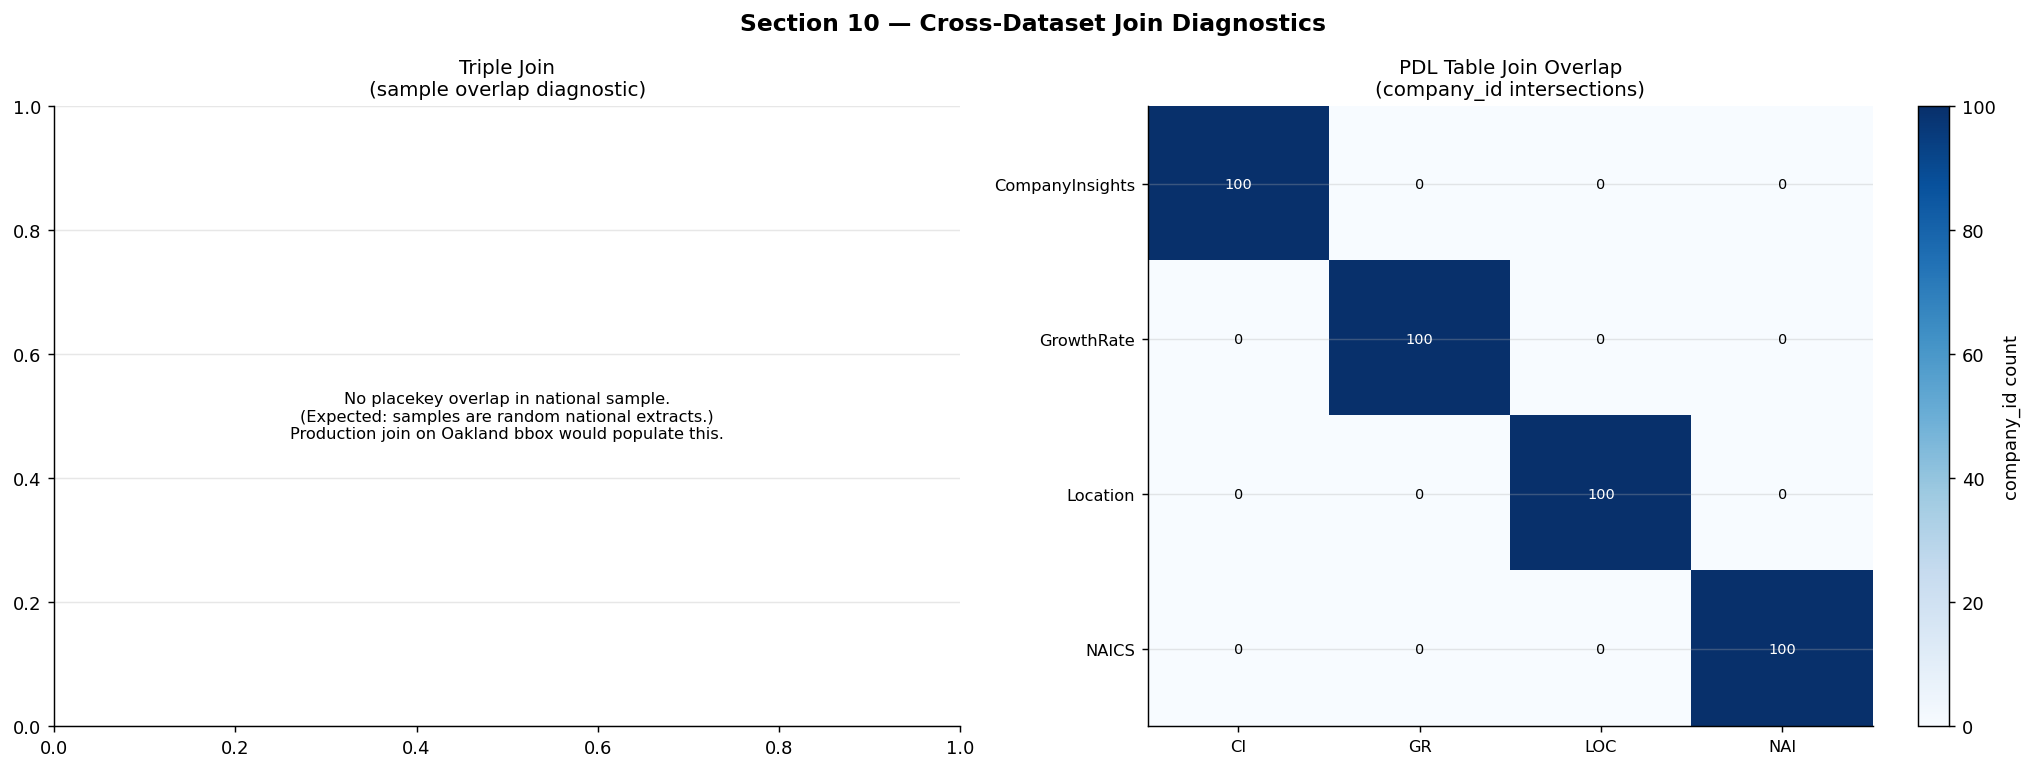

Saved: dewey_09_cross_joins.png


In [36]:

# ─── 10c. Cross-join visualisation ──────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: visit counts vs median spend (triple-join result)
ax = axes[0]
if len(triple) > 0 and "raw_visit_counts" in triple.columns and "median_spend_per_customer" in triple.columns:
    x = pd.to_numeric(triple["raw_visit_counts"], errors="coerce")
    y = pd.to_numeric(triple["median_spend_per_customer"], errors="coerce")
    valid = x.notna() & y.notna() & (x > 0) & (y > 0)
    if valid.sum() > 0:
        cat_col = "top_category" if "top_category" in triple.columns else None
        if cat_col:
            cats = triple.loc[valid, cat_col].fillna("Other")
            top_cats = cats.value_counts().head(8).index
            palette = {c: COLORS[i % len(COLORS)] for i, c in enumerate(top_cats)}
            for cat in top_cats:
                mask = valid & (cats == cat)
                ax.scatter(x[mask], y[mask], label=cat[:25], alpha=0.65, s=40,
                           color=palette[cat])
        else:
            ax.scatter(x[valid], y[valid], alpha=0.5, s=30, color=COLORS[0])
        ax.set_xlabel("Monthly Visit Counts"); ax.set_ylabel("Median Spend / Customer ($)")
        ax.set_title("Triple Join (POI × Spend × Advan)\nVisits vs Spend per Customer", fontsize=11)
        if cat_col:
            ax.legend(fontsize=7, ncol=1, loc="upper right")
    else:
        ax.text(0.5, 0.5, "No numeric data after cleaning", ha="center", va="center", transform=ax.transAxes)
else:
    ax.text(0.5, 0.5,
            "No placekey overlap in national sample.\n(Expected: samples are random national extracts.)\n"
            "Production join on Oakland bbox would populate this.",
            ha="center", va="center", transform=ax.transAxes, fontsize=9,
            wrap=True)
    ax.set_title("Triple Join\n(sample overlap diagnostic)", fontsize=11)

# Right: PDL completeness heatmap (which company_ids appear in which table)
ax = axes[1]
pdl_table_names = list(pdl_tables.keys())
mat = np.zeros((len(pdl_table_names), len(pdl_table_names)))
for i, n1 in enumerate(pdl_table_names):
    c1 = id_col_map[n1]
    for j, n2 in enumerate(pdl_table_names):
        c2 = id_col_map[n2]
        if not c1 or not c2:
            continue
        s1 = set(pdl_tables[n1][c1].dropna().unique())
        s2 = set(pdl_tables[n2][c2].dropna().unique())
        if i == j:
            mat[i, j] = len(s1)
        else:
            mat[i, j] = len(s1 & s2)

labels = ["CI", "GR", "LOC", "NAI"]
im = ax.imshow(mat, cmap="Blues", aspect="auto")
ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, fontsize=9)
ax.set_yticks(range(len(labels))); ax.set_yticklabels(["CompanyInsights","GrowthRate","Location","NAICS"], fontsize=9)
for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, f"{int(mat[i,j]):,}", ha="center", va="center", fontsize=8,
                color="white" if mat[i,j] > mat.max()*0.6 else "black")
plt.colorbar(im, ax=ax, label="company_id count")
ax.set_title("PDL Table Join Overlap\n(company_id intersections)", fontsize=11)

plt.suptitle("Section 10 — Cross-Dataset Join Diagnostics", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "dewey_09_cross_joins.png", bbox_inches="tight")
plt.show()
print("Saved: dewey_09_cross_joins.png")


In [37]:

# ─── 10d. Cross-join takeaway ────────────────────────────────────────────

print("=" * 60)
print("SECTION 10 KEY TAKEAWAYS — Cross-Dataset Joins")
print("=" * 60)
print("""
  THE PLACEKEY SPINE
  ──────────────────
  placekey is a global, stable POI identifier that links:
    • SafeGraph POI Geometry  → lat/lon, polygon, open/close date, NAICS
    • SafeGraph Spend Patterns → median spend/customer, # customers, YoY Δ
    • Advan Monthly Patterns  → visit counts, dwell time, visitor home CBG
    • Advan Weekly Patterns   → day-of-week visit profiles

  A single production query filtered to Oakland lat/lon bbox produces
  one enriched row per physical storefront with ALL of:
    identity | location | polygon | category | customer spend |
    foot traffic | dwell time | visitor origin CBGs

  This "triple" is what we cannot build from DataAxle alone.

  THE COMPANY_ID SPINE (PeopleDataLabs)
  ──────────────────────────────────────
  company_id ties together:
    • CompanyInsights → funding, revenue, headcount, tech stack indicators
    • EmployeeGrowthRate → 3/6/12/24-month % change in headcount
    • Location → address, state, county, country
    • NAICS → 2-digit sector classification

  PDL's company_id is derived from name+address normalisation.
  Matching to DataAxle by (name, address) allows partial crosswalk.

  SAMPLE OVERLAP NOTE
  ────────────────────
  National random samples rarely share the same placekeys.
  Zero triple-join matches in samples is EXPECTED behaviour.
  Production queries against the full Dewey database for a
  defined Oakland bbox (OAK_LAT_MIN→OAK_LAT_MAX, same for lon)
  will populate the triple reliably.
""")


SECTION 10 KEY TAKEAWAYS — Cross-Dataset Joins

  THE PLACEKEY SPINE
  ──────────────────
  placekey is a global, stable POI identifier that links:
    • SafeGraph POI Geometry  → lat/lon, polygon, open/close date, NAICS
    • SafeGraph Spend Patterns → median spend/customer, # customers, YoY Δ
    • Advan Monthly Patterns  → visit counts, dwell time, visitor home CBG
    • Advan Weekly Patterns   → day-of-week visit profiles

  A single production query filtered to Oakland lat/lon bbox produces
  one enriched row per physical storefront with ALL of:
    identity | location | polygon | category | customer spend |
    foot traffic | dwell time | visitor origin CBGs

  This "triple" is what we cannot build from DataAxle alone.

  THE COMPANY_ID SPINE (PeopleDataLabs)
  ──────────────────────────────────────
  company_id ties together:
    • CompanyInsights → funding, revenue, headcount, tech stack indicators
    • EmployeeGrowthRate → 3/6/12/24-month % change in headcount
    • Location 


## Section 11 — Cross-Examination Against DataAxle (Oakland Baseline)

**Hypothesis:** *DataAxle is our existing Oakland business directory.  Dewey adds orthogonal signals.  By mapping both to NAICS 2-digit sectors we can identify (a) which sectors are already well-covered by DataAxle, (b) which sectors have richer Dewey signals (spend, foot-traffic, tech stack), and (c) which fields DataAxle has that Dewey lacks.*

We load `dataaxle_slim.csv` (the cleaned Oakland 29k-record extract from the previous notebook) and `corridor_profile.csv` (corridor-level aggregates) and compare sector distributions and field coverage.


In [38]:

# ─── 11a. Load DataAxle + corridor, compute sector distributions ─────────

da = load_safe(DATAAXLE_PATH)
print(f"DataAxle slim: {len(da):,} rows  |  columns: {da.shape[1]}")
if len(da) > 0:
    print("  Sample columns:", list(da.columns[:12]))

corr = load_safe(CORRIDOR_PATH)
print(f"Corridor profile: {len(corr):,} rows  |  columns: {corr.shape[1]}")

# ─── NAICS sector mapping for DataAxle ───────────────────────────────────
naics_col_da = next((c for c in da.columns if "naics" in c.lower() or "sic" in c.lower()), None)
if naics_col_da:
    da["naics2_da"] = da[naics_col_da].astype(str).str[:2].str.zfill(2)
    da["sector_da"] = da["naics2_da"].map(NAICS2_SECTOR).fillna("Other/Unknown")
    da_sector_cnt = da["sector_da"].value_counts().head(15)
    print(f"\nDataAxle top sectors (by {naics_col_da}):")
    for s, n in da_sector_cnt.items():
        print(f"  {s:<40} {n:>6,}")
else:
    print("\n  ⚠  No NAICS/SIC column found in DataAxle slim — skipping sector map.")
    da_sector_cnt = pd.Series(dtype=int)

# ─── NAICS sector mapping for PDL NAICS sample ───────────────────────────
naics_col_pdl = next((c for c in pdl_nai.columns if "naics" in c.lower()), None)
if naics_col_pdl:
    pdl_nai["naics2_pdl"] = pdl_nai[naics_col_pdl].astype(str).str[:2].str.zfill(2)
    pdl_nai["sector_pdl"] = pdl_nai["naics2_pdl"].map(NAICS2_SECTOR).fillna("Other/Unknown")
    pdl_sector_cnt = pdl_nai["sector_pdl"].value_counts().head(15)
    print(f"\nPDL NAICS top sectors (national sample):")
    for s, n in pdl_sector_cnt.items():
        print(f"  {s:<40} {n:>6,}")
else:
    pdl_sector_cnt = pd.Series(dtype=int)

# ─── Field-capability comparison matrix ──────────────────────────────────
print("\n\nField Capability Comparison (DataAxle vs Dewey)")
print("-" * 60)
capability_matrix = [
    # capability                          DataAxle   Dewey source
    ("Business name / address",          "✅",  "✅ PDL Location, BQ Firmographic"),
    ("Phone / email",                    "✅",  "⬜ not in samples"),
    ("NAICS / SIC classification",       "✅",  "✅ PDL NAICS, BQ Industry"),
    ("Employee size estimate",           "✅",  "✅ Rhetorik, PDL CompanyInsights"),
    ("Sales / revenue estimate",         "✅",  "✅ PDL (inferred), BQ Industry benchmark"),
    ("Years in business / tenure",       "✅",  "⬜"),
    ("Credit rating / score",            "✅",  "⬜"),
    ("Home-based business flag",         "✅",  "⬜"),
    ("Actual consumer card spend",       "⬜",  "✅ SafeGraph SpendPatterns"),
    ("Foot-traffic visit counts",        "⬜",  "✅ Advan Monthly/Weekly"),
    ("Visitor home CBG (origin)",        "⬜",  "✅ Advan (visitor_home_cbgs JSON)"),
    ("Dwell time distribution",          "⬜",  "✅ Advan Monthly"),
    ("Tech stack / digital readiness",   "⬜",  "✅ Rhetorik detected_technologies"),
    ("Funding stage / VC backing",       "⬜",  "✅ PDL CompanyInsights"),
    ("12-month headcount growth rate",   "⬜",  "✅ PDL EmployeeGrowthRate"),
    ("POI open / close dates",           "⬜",  "✅ SafeGraph GlobalPlacesPOI"),
    ("Building polygon / geometry",      "⬜",  "✅ SafeGraph GlobalPlacesPOI"),
    ("Property AVM / equity",            "⬜",  "✅ Infutor PropertyData"),
    ("Mortgage amount / interest rate",  "⬜",  "✅ Infutor PropertyData"),
    ("Industry peer benchmarks",         "⬜",  "✅ BrightQuery Industry"),
    ("Monthly employment time-series",   "⬜",  "✅ BrightQuery EmploymentMonthly"),
]
for cap, da_has, dw_has in capability_matrix:
    print(f"  {cap:<42} DataAxle: {da_has}  Dewey: {dw_has}")


DataAxle slim: 29,541 rows  |  columns: 20
  Sample columns: ['company name', 'address', 'city', 'zip code', 'latitude', 'longitude', 'geohash7', 'neighborhood', 'primary naics', 'primary naics description', 'sector', 'naics2']
Corridor profile: 134 rows  |  columns: 14

DataAxle top sectors (by primary naics):
  Health Care                              10,866
  Prof/Scientific                           3,158
  Other Services                            3,054
  Other/Unknown                             2,083
  Retail                                    1,858
  Food Services                             1,456
  Finance/Insurance                         1,144
  Construction                              1,010
  Real Estate                                 889
  Admin/Support                               632
  Education                                   598
  Manufacturing                               529
  Arts/Ent                                    492
  Wholesale                          

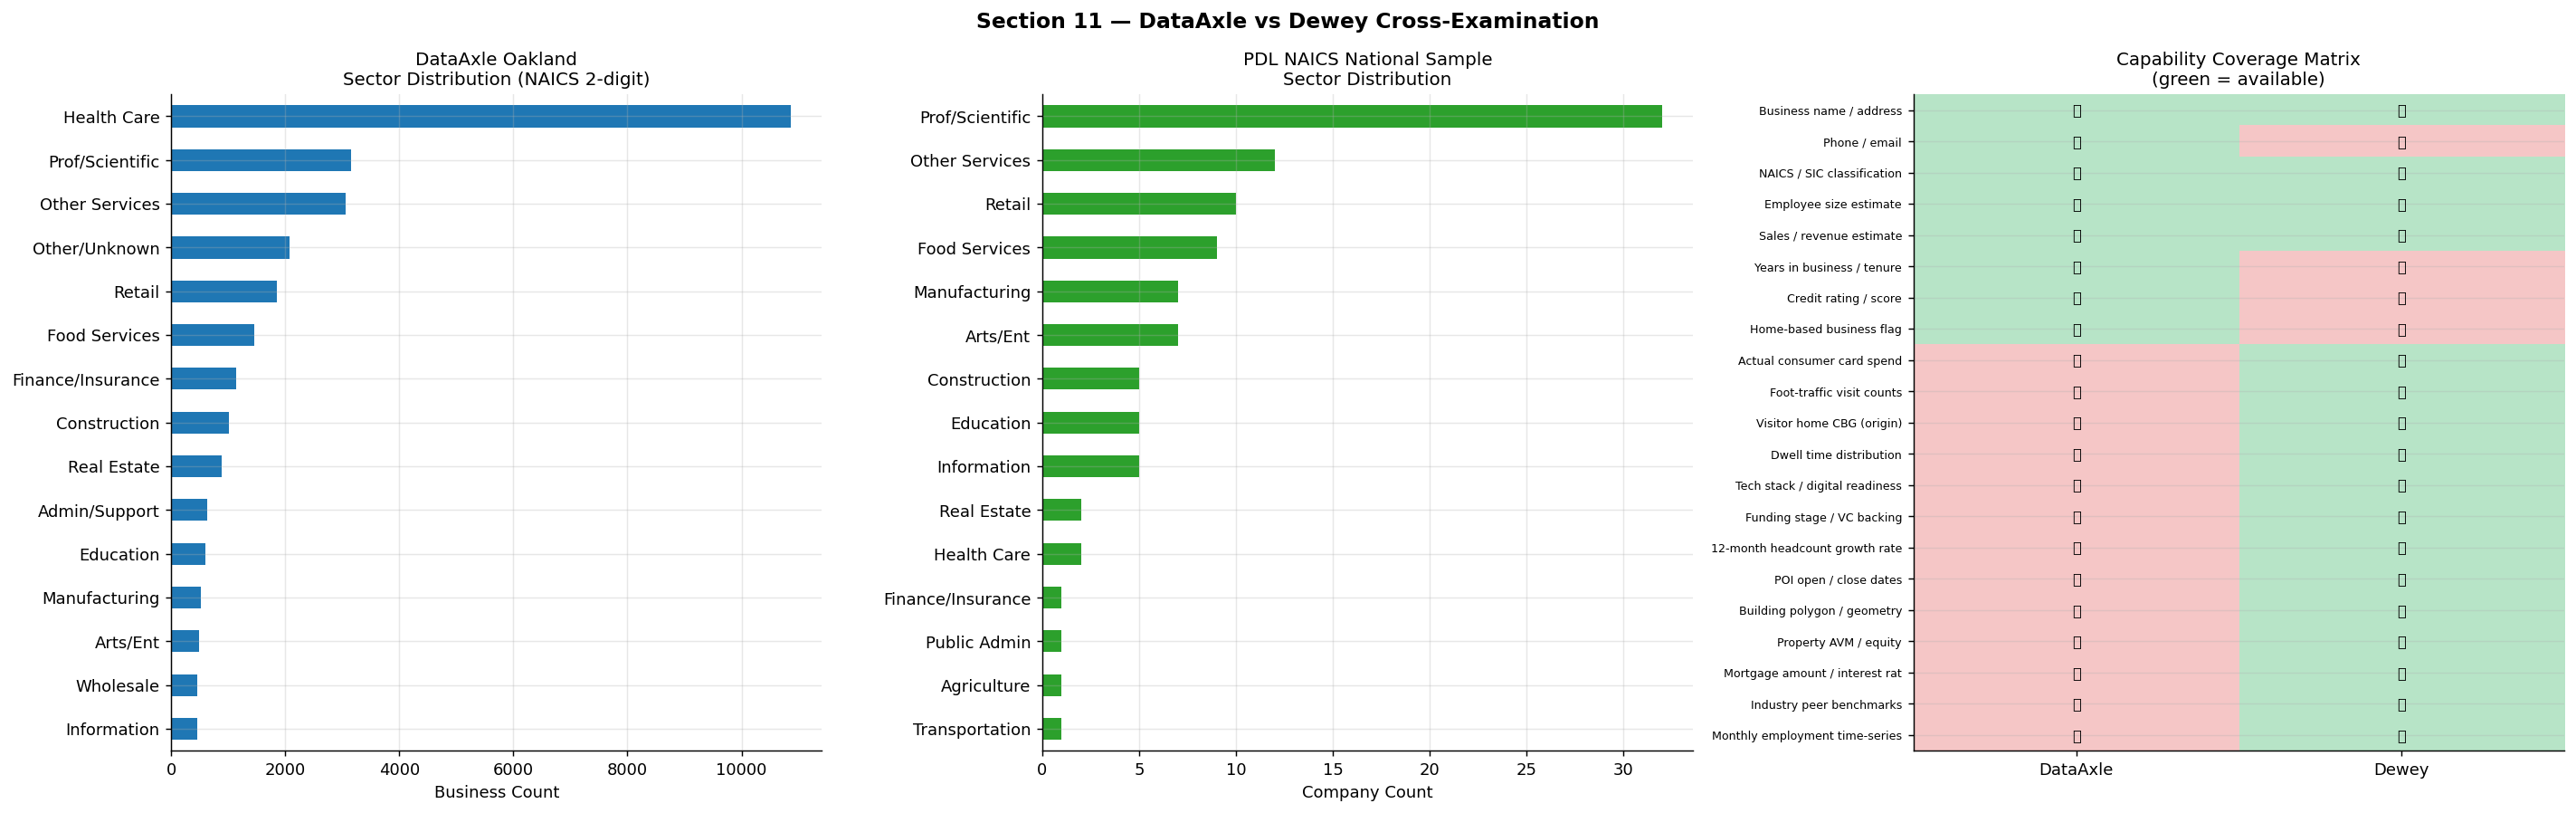

Saved: dewey_10_dataaxle_comparison.png


In [39]:

# ─── 11b. Visualisation: sector distributions + capability heatmap ───────

fig, axes = plt.subplots(1, 3, figsize=(22, 7))

# Left: DataAxle sector distribution
ax = axes[0]
if len(da_sector_cnt) > 0:
    da_sector_cnt.sort_values().plot(kind="barh", ax=ax, color=COLORS[0])
    ax.set_title("DataAxle Oakland\nSector Distribution (NAICS 2-digit)", fontsize=11)
    ax.set_xlabel("Business Count"); ax.set_ylabel("")
    for spine in ["top", "right"]: ax.spines[spine].set_visible(False)
else:
    ax.text(0.5, 0.5, "No NAICS column in DataAxle slim", ha="center", va="center", transform=ax.transAxes)

# Centre: PDL sector distribution (national sample)
ax = axes[1]
if len(pdl_sector_cnt) > 0:
    pdl_sector_cnt.sort_values().plot(kind="barh", ax=ax, color=COLORS[2])
    ax.set_title("PDL NAICS National Sample\nSector Distribution", fontsize=11)
    ax.set_xlabel("Company Count"); ax.set_ylabel("")
    for spine in ["top", "right"]: ax.spines[spine].set_visible(False)
else:
    ax.text(0.5, 0.5, "No NAICS column in PDL", ha="center", va="center", transform=ax.transAxes)

# Right: capability matrix heatmap
ax = axes[2]
cap_labels = [r[0][:30] for r in capability_matrix]
# 1 = has, 0 = lacks
da_vec  = [1 if "✅" in r[1] else 0 for r in capability_matrix]
dew_vec = [1 if "✅" in r[2] else 0 for r in capability_matrix]

mat_cap = np.array([da_vec, dew_vec]).T   # shape (n_caps, 2)
cmap_cap = plt.cm.colors.ListedColormap(["#f5c6c6", "#b7e4c7"])
im = ax.imshow(mat_cap, cmap=cmap_cap, aspect="auto", vmin=0, vmax=1)
ax.set_xticks([0, 1]); ax.set_xticklabels(["DataAxle", "Dewey"], fontsize=10)
ax.set_yticks(range(len(cap_labels))); ax.set_yticklabels(cap_labels, fontsize=7)
for i in range(mat_cap.shape[0]):
    for j in range(mat_cap.shape[1]):
        ax.text(j, i, "✅" if mat_cap[i, j] == 1 else "⬜",
                ha="center", va="center", fontsize=9)
ax.set_title("Capability Coverage Matrix\n(green = available)", fontsize=11)

plt.suptitle("Section 11 — DataAxle vs Dewey Cross-Examination", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "dewey_10_dataaxle_comparison.png", bbox_inches="tight")
plt.show()
print("Saved: dewey_10_dataaxle_comparison.png")


In [40]:

# ─── 11c. DataAxle cross-examination takeaway ────────────────────────────

print("=" * 60)
print("SECTION 11 KEY TAKEAWAYS — DataAxle Cross-Examination")
print("=" * 60)
print("""
  WHAT DATAAXLE UNIQUELY CONTRIBUTES
  ────────────────────────────────────
  • Credit score / financial risk flags
  • Home-based business indicator
  • Years in the DataAxle database (tenure proxy)
  • Phone + email (direct contact channel)
  • Direct sales estimates (DataAxle model)

  WHAT DEWEY UNIQUELY CONTRIBUTES
  ────────────────────────────────
  • Actual card-transaction spend (SafeGraph)       ← most novel
  • Consumer visit counts + dwell time (Advan)      ← second most novel
  • Visitor home CBG → income/demo of customer base ← third most novel
  • Technology stack / digital readiness (Rhetorik)
  • Funding stage + VC backing (PDL)
  • Headcount 3/6/12/24-month growth (PDL)
  • Business open/close dates + polygon (SafeGraph)
  • Property AVM, equity, mortgage burden (Infutor)
  • Industry peer benchmarks (BrightQuery)

  RECOMMENDED INTEGRATION ARCHITECTURE
  ──────────────────────────────────────
  Primary spine → DataAxle (29k Oakland businesses, name+address+NAICS)

  Enrich via placekey join (name+address normalisation → placekey):
    DataAxle business → SafeGraph POI → SafeGraph Spend
                                      → Advan Monthly/Weekly

  Enrich via company_id fuzzy join (name+address → company_id):
    DataAxle business → PDL CompanyInsights (funding, tech)
                      → PDL GrowthRate (headcount trend)
                      → BrightQuery (employment time-series)

  Enrich via addrid (address → property record):
    DataAxle business address → Infutor Property
                              → owner equity, mortgage burden

  Result: one row per Oakland business with:
    identity + credit + sales + sector +          (DataAxle)
    actual spend + visits + dwell + customer origin (Dewey/SafeGraph/Advan)
    digital readiness + funding + growth            (Dewey/Rhetorik/PDL)
    property equity + debt burden                  (Dewey/Infutor)
""")


SECTION 11 KEY TAKEAWAYS — DataAxle Cross-Examination

  WHAT DATAAXLE UNIQUELY CONTRIBUTES
  ────────────────────────────────────
  • Credit score / financial risk flags
  • Home-based business indicator
  • Years in the DataAxle database (tenure proxy)
  • Phone + email (direct contact channel)
  • Direct sales estimates (DataAxle model)

  WHAT DEWEY UNIQUELY CONTRIBUTES
  ────────────────────────────────
  • Actual card-transaction spend (SafeGraph)       ← most novel
  • Consumer visit counts + dwell time (Advan)      ← second most novel
  • Visitor home CBG → income/demo of customer base ← third most novel
  • Technology stack / digital readiness (Rhetorik)
  • Funding stage + VC backing (PDL)
  • Headcount 3/6/12/24-month growth (PDL)
  • Business open/close dates + polygon (SafeGraph)
  • Property AVM, equity, mortgage burden (Infutor)
  • Industry peer benchmarks (BrightQuery)

  RECOMMENDED INTEGRATION ARCHITECTURE
  ──────────────────────────────────────
  Primary spine → Da


---
## 🔑 Final Key Takeaways — Dewey Data Exploration

### What is the Dewey dataset?
Dewey aggregates **14 licensed data tables** from 6 providers into a single query interface. Samples explored here are **national random extracts** (not Oakland-filtered) — they serve as schema documentation. Production queries filter by lat/lon bounding box to return Oakland-specific data.

---

### Source Inventory & Capability Summary

| # | File | Provider | Records (sample) | Key Signal | Oakland Use |
|---|------|----------|-----------------|-----------|------------|
| 1 | CompanyData-Rhetorik | Rhetorik | ~8,100 | Tech stack, employee size, office count | Digital readiness proxy |
| 2 | CompanyInsights-PDL | PeopleDataLabs | ~1,000 | Funding stage, inferred revenue | Growth-stage classification |
| 3 | EmployeeGrowthRate-PDL | PeopleDataLabs | ~1,000 | 3/6/12/24-mo headcount % Δ | Leading contraction indicator |
| 4 | Location-PDL | PeopleDataLabs | ~1,000 | Address, country | Geo filter / address normalise |
| 5 | Naics-PDL | PeopleDataLabs | ~1,000 | NAICS 2-digit sector | Sector crosswalk to DataAxle |
| 6 | FirmographicInfo-BQ | BrightQuery | ~500 | Company type, LFO, structure | Org-type distribution |
| 7 | EmploymentMonthly-BQ | BrightQuery | ~1,000 | Monthly employment time-series | Employment trend per business |
| 8 | Industry-BQ | BrightQuery | ~500 | Revenue & profit benchmarks by NAICS | Peer-group performance ranking |
| 9 | GlobalPlacesPOI-SafeGraph | SafeGraph | ~1,500 | Location polygon, open/close dates | Vacancy / churn tracking |
| 10 | SpendPatterns-SafeGraph | SafeGraph | ~24,600 | Median $ spend/customer, YoY Δ | **Most novel: actual spend signal** |
| 11 | FootTrafficMonthly-Advan | Advan Research | ~150 | Visit counts, dwell, visitor CBG | **2nd most novel: foot traffic** |
| 12 | FootTrafficWeekly-Advan | Advan Research | ~100 | Day-of-week visit profile | Peak-day analysis |
| 13 | FootTrafficNeighbourhood-Advan | Advan Research | ~100 | Area stops, distance from home | Neighbourhood-level mobility |
| 14 | PropertyData-Infutor | Infutor Data Solutions | ~300 | AVM, equity, mortgage, year built | Owner/landlord financial resilience |

---

### 5-Tier Priority for Data Acquisition

| Tier | Tables | Rationale |
|------|--------|-----------|
| **P1 — Acquire now** | SafeGraph SpendPatterns, Advan Monthly | Actual spend + visits — no equivalent elsewhere |
| **P2 — High value** | SafeGraph GlobalPlacesPOI, PDL GrowthRate | Open/close dates + headcount trend — unique leading indicators |
| **P3 — Augments DataAxle** | Rhetorik CompanyData, BrightQuery Industry | Tech stack + peer benchmarks close gap in DataAxle |
| **P4 — Enrichment** | PDL CompanyInsights, BrightQuery Employment | Funding + employment series for deeper profiling |
| **P5 — Contextual** | Infutor Property, Advan Neighbourhood | Useful for specific analyses (lease pressure, mobility) |

---

### New Analyses Unlocked by Dewey (vs DataAxle alone)

1. **Corridor vitality score** — spend per visitor × foot-traffic trend × YoY Δ spend → single composite health metric per corridor
2. **Displacement risk** — property AVM growth rate × low business equity → identify corridors where land value outpaces business income
3. **Digital divide map** — Rhetorik tech stack adoption rate per corridor → target digital-assistance programs
4. **Sector contraction early warning** — PDL 12-month headcount decline + SafeGraph spend decline → two independent signals of the same stress
5. **Customer income proxy** — Advan visitor_home_cbg → join to ACS median household income → is the corridor losing high-income or low-income customers?
6. **Peer-group benchmarking** — BrightQuery Industry revenue quartiles → flag Oakland businesses performing in bottom 25% of national peers

---

### Key Architectural Insight

```
DataAxle (WHO is there) + Advan (HOW MANY visit) + SafeGraph Spend (HOW MUCH they spend)
= the most complete picture of a physical corridor available from secondary data
```

**The placekey is the glue.** Convert DataAxle name+address → placekey → join all three tables. Everything else is enrichment.
